### Imports y configuración general

In [62]:
# =========================================================
# BLOQUE 1 - Imports y configuración general
# =========================================================
"""
Este bloque define las librerías base y la configuración visual
del notebook. No contiene lógica de negocio.
"""

import pandas as pd
import numpy as np
from typing import List, Callable, Optional
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


### Normalización

In [63]:
# =========================================================
# BLOQUE 2.1 - Normalización de columnas ID
# =========================================================
def normalize_id_columns(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Normaliza columnas de identificación para garantizar consistencia
    entre todas las fuentes de datos.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    columns : List[str]
        Lista de columnas ID a normalizar.

    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas ID normalizadas.
    """
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: str(int(x)) if pd.notnull(x) else None
            )
    return df


In [64]:
# =========================================================
# BLOQUE 2.2 - Conversión de fechas YYYYMM
# =========================================================
def parse_yyyymm_to_date(
    df: pd.DataFrame,
    source_col: str,
    target_col: str = "fecha"
) -> pd.DataFrame:
    """
    Convierte una columna en formato YYYYMM a datetime (primer día del mes).

    Qué hace:
    - Convierte YYYYMM (int o string) a datetime
    - Crea una nueva columna de fecha estándar

    - Unifica el manejo temporal entre fuentes

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    source_col : str
        Nombre de la columna YYYYMM.
    target_col : str, default 'fecha'
        Nombre de la columna datetime resultante.

    Retorna
    -------
    pd.DataFrame
        DataFrame con columna de fecha añadida.
    """
    df = df.copy()
    if source_col in df.columns:
        df[source_col] = df[source_col].astype(int)
        df[target_col] = pd.to_datetime(
            df[source_col].astype(str),
            format="%Y%m"
        )
    return df


### Carga de Catalogos

In [65]:
# =========================================================
# BLOQUE 3 - Base Pivot (fuente principal)
# =========================================================

def load_csv_generic(
    path: str,
    id_columns: List[str],
    date_parser: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None
) -> pd.DataFrame:
    """
    Loader genérico de CSV.

    Responsabilidad:
    - Leer archivo
    - Normalizar columnas ID
    - Aplicar parser de fecha específico si se define

    Este método NO conoce el negocio.
    """
    df = pd.read_csv(path)
    df = normalize_id_columns(df, id_columns)

    if date_parser is not None:
        df = date_parser(df)

    return df


In [66]:
# =========================================================
# BLOQUE 3 - OTT / Train
# =========================================================

def load_pivot(path: str) -> pd.DataFrame:
    """
    Carga la base pivot analítica (train u OOT).

    Unidad analítica:
    cliente – obligación – mes
    """
    return load_csv_generic(
        path=path,
        id_columns=[
            "nit_enmascarado",
            "num_oblig_orig_enmascarado",
            "num_oblig_enmascarado"
        ],
        date_parser=lambda df: parse_yyyymm_to_date(
            df, "fecha_var_rpta_alt"
        )
    )


In [67]:
# =========================================================
# BLOQUE 3 - Historico de Pagos
# =========================================================

def load_payments(path: str) -> pd.DataFrame:
    """
    Carga el histórico de pagos por obligación.

    Tabla transaccional mensual.
    NO se une directamente al pivot.
    """
    return load_csv_generic(
        path=path,
        id_columns=[
            "nit_enmascarado",
            "num_oblig_enmascarado"
        ],
        date_parser=lambda df: (
            df.assign(
                fecha=pd.to_datetime(df["fecha_corte"].astype(str))
            )
        )
    )


In [68]:
# =========================================================
# BLOQUE 3 - Master de cliente
# =========================================================

def load_customers(path: str) -> pd.DataFrame:
    """
    Carga el master de clientes con snapshot mensual.

    Se usará para enriquecer el pivot
    respetando la temporalidad.
    """
    return load_csv_generic(
        path=path,
        id_columns=["nit_enmascarado"],
        date_parser=lambda df: (
            df.assign(
                fecha=pd.to_datetime(
                    df["year"].astype(str)
                    + df["month"].astype(str).str.zfill(2),
                    format="%Y%m"
                )
            )
        )
    )


In [69]:
# =========================================================
# BLOQUE 3 - Scores analíticos
# =========================================================

def load_scores(path: str) -> pd.DataFrame:
    """
    Carga scores analíticos históricos por obligación.

    Contiene:
    - prob_propension
    - prob_auto_cura
    - prob_alrt_temprana
    """
    return load_csv_generic(
        path=path,
        id_columns=[
            "nit_enmascarado",
            "num_oblig_enmascarado"
        ],
        date_parser=lambda df: parse_yyyymm_to_date(
            df, "fecha_corte"
        )
    )


#### Uso Catalogos

In [70]:
# Base pivot
pivot_train = load_pivot(
    "src/loaders/prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv"
)

pivot_oot = load_pivot(
    "src/loaders/prueba_op_base_pivot_var_rpta_alt_enmascarado_oot.csv"
)

# Pagos
payments = load_payments(
    "src/loaders/prueba_op_maestra_cuotas_pagos_mes_hist_enmascarado_completa.csv"
)

# Master cliente
customers = load_customers(
    "src/loaders/prueba_op_master_customer_data_enmascarado_completa.csv"
)

# Scores
scores = load_scores(
    "src/loaders/prueba_op_probabilidad_oblig_base_hist_enmascarado_completa.csv"
)


In [71]:
# =========================================================
# CHECK - Carga de catálogos
# =========================================================

def print_catalog_summary(df: pd.DataFrame, name: str) -> None:
    """
    Imprime un resumen básico del catálogo cargado.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame cargado.
    name : str
        Nombre descriptivo del catálogo.
    """
    print(f"\n📁 Catálogo: {name}")
    print(f"   Filas    : {df.shape[0]:,}")
    print(f"   Columnas : {df.shape[1]:,}")


In [72]:
print("====== RESUMEN DE CATÁLOGOS CARGADOS ======")

print_catalog_summary(pivot_train, "Pivot Train")
print_catalog_summary(pivot_oot, "Pivot OOT")
print_catalog_summary(payments, "Pagos Históricos")
print_catalog_summary(customers, "Master Cliente")
print_catalog_summary(scores, "Scores Analíticos")


====== RESUMEN DE CATÁLOGOS CARGADOS ======

📁 Catálogo: Pivot Train
   Filas    : 568,251
   Columnas : 50

📁 Catálogo: Pivot OOT
   Filas    : 112,549
   Columnas : 5

📁 Catálogo: Pagos Históricos
   Filas    : 4,855,035
   Columnas : 14

📁 Catálogo: Master Cliente
   Filas    : 430,000
   Columnas : 38

📁 Catálogo: Scores Analíticos
   Filas    : 4,804,836
   Columnas : 8


## Definición y Gobernanza del Feature Space (Pre‑Modelado)

# Definición y Gobernanza del Feature Space (Pre‑Modelado)

## Contexto
El objetivo de esta solución analítica es predecir, con un mes de anticipación,
la probabilidad de que una obligación en mora acepte una opción de pago.
Este score se utilizará como una variable adicional dentro del esquema de
priorización operativa del negocio.

El Feature Space se define explícitamente antes de cualquier análisis exploratorio
o entrenamiento, con el fin de garantizar reproducibilidad, ausencia de leakage
y viabilidad productiva para train y OOT.

---

## Principio
> **El modelo no se entrena sobre columnas crudas, sino sobre features
explícitamente definidas, reproducibles y disponibles tanto para entrenamiento
como para predicción.**

---

## Fuentes oficiales de información
- Base Pivot (estado de la obligación y contexto operativo)
- Pagos Históricos
- Master de Cliente
- Scores Analíticos

El dataset `pivot_train` se utiliza exclusivamente para entrenamiento por contener
la variable objetivo, y nunca se usa como fuente de enriquecimiento para OOT.

---

## Grupos de features definidos

### 1. Features de estado financiero de la obligación
**Fuente:** Base Pivot  
**Nivel:** obligación – mes  

Describen la severidad financiera y el estado actual de la obligación.

Ejemplos:
- Días de mora
- Mora mínima, máxima y rango
- Valor de la obligación
- Valor vencido
- Saldo de capital
- Endeudamiento

---

### 2. Features de elegibilidad y oferta de opciones de pago
**Fuente:** Base Pivot  
**Nivel:** obligación – mes  

Capturan el contexto de oferta disponible para el cliente.

Ejemplos:
- Cantidad de opciones de pago disponibles
- Tipo de opciones habilitadas (codificadas)
- Historial de alternativas ofrecidas
- Indicadores de restricción o habilitación

Estas variables representan condiciones necesarias para la aceptación.

---

### 3. Features de gestión y contacto
**Fuente:** Base Pivot  
**Nivel:** obligación – mes  

Reflejan la intensidad y efectividad de la gestión realizada hasta el momento.

Ejemplos:
- Número de gestiones realizadas
- Indicador de contacto efectivo (RPC)
- Promesas de pago cumplidas
- Acuerdos existentes

No representan resultados futuros, sino estado operativo previo.

---

### 4. Features de comportamiento de pago
**Fuente:** Pagos Históricos  
**Nivel:** obligación – ventanas temporales  

Se construyen mediante agregaciones usando únicamente información previa al mes objetivo.

Ejemplos:
- Porcentaje de meses pagados (3m, 6m)
- Meses desde el último pago
- Pago promedio relativo a la cuota
- Pago acumulado por ventana
- Rachas de no pago
- Variabilidad del pago

---

### 5. Features de perfil del cliente
**Fuente:** Master de Cliente  
**Nivel:** cliente – mes  

Corresponden al último snapshot disponible del cliente previo o igual al mes objetivo.

Ejemplos:
- Edad (o buckets de edad)
- Ingresos (transformados)
- Activos, pasivos y ratios financieros
- Antigüedad como cliente
- Segmento, subsegmento y tipo de cliente
- Ubicación geográfica (región, departamento)
- Número de dependientes

Estas variables permiten capturar patrones estructurales y segmentados.

---

### 6. Meta‑features analíticas
**Fuente:** Scores Analíticos  
**Nivel:** obligación – mes  

Corresponden a probabilidades generadas por modelos previos, siempre usando valores del mes t‑1.

Ejemplos:
- Probabilidad de propensión de pago (t‑1)
- Probabilidad de auto‑cura (t‑1)
- Probabilidad de alerta temprana (t‑1)
- Indicador de disponibilidad de score

---

## Exclusiones explícitas
No se consideran features del modelo:
- Variables objetivo o derivadas del resultado
- Rankings post‑gestión
- Marcas que reflejen aceptación o rechazo
- Variables que no puedan reconstruirse para OOT

# Estructura base del Feature Registry

In [73]:
# =========================================================
# BLOQUE - Feature Registry (estructura base)
# =========================================================

FEATURE_REGISTRY = {
    "pivot": [],
    "payments": [],
    "customers": [],
    "scores": []
}


In [74]:
# =========================================================
# Features - Estado financiero de la obligación
# Fuente: Pivot
# =========================================================

FEATURE_REGISTRY["pivot"].extend([
    {
        "name": "dias_mora_fin",
        "source_column": "dias_mora_fin",
        "description": "Días de mora al cierre del mes",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "min_mora",
        "source_column": "min_mora",
        "description": "Mínimo histórico reciente de mora",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "max_mora",
        "source_column": "max_mora",
        "description": "Máximo histórico reciente de mora",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "rango_mora",
        "source_column": "rango_mora",
        "description": "Rango categórico de severidad de mora",
        "feature_type": "categorical",
        "temporal": "current"
    },
    {
        "name": "vlr_obligacion",
        "source_column": "vlr_obligacion",
        "description": "Valor total de la obligación",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "vlr_vencido",
        "source_column": "vlr_vencido",
        "description": "Valor vencido a la fecha",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "saldo_capital",
        "source_column": "saldo_capital",
        "description": "Saldo de capital pendiente",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "endeudamiento",
        "source_column": "endeudamiento",
        "description": "Nivel de endeudamiento del cliente",
        "feature_type": "numeric",
        "temporal": "current"
    }
])


In [75]:
# =========================================================
# Features - Elegibilidad y oferta de opciones de pago
# Fuente: Pivot
# =========================================================

FEATURE_REGISTRY["pivot"].extend([
    {
        "name": "cant_alter_posibles",
        "source_column": "cant_alter_posibles",
        "description": "Cantidad de opciones de pago habilitadas",
        "feature_type": "numeric",
        "temporal": "current"
    }
])


In [76]:
# =========================================================
# Features - Gestión y contacto
# Fuente: Pivot
# =========================================================

FEATURE_REGISTRY["pivot"].extend([
    {
        "name": "cant_gestiones",
        "source_column": "cant_gestiones",
        "description": "Número de gestiones realizadas al cliente",
        "feature_type": "numeric",
        "temporal": "current"
    },
    {
        "name": "rpc",
        "source_column": "rpc",
        "description": "Indicador de contacto efectivo con el cliente",
        "feature_type": "categorical",
        "temporal": "current"
    },
    {
        "name": "promesas_cumplidas",
        "source_column": "promesas_cumplidas",
        "description": "Número de promesas de pago cumplidas",
        "feature_type": "numeric",
        "temporal": "current"
    }
])


In [77]:
# =========================================================
# Features - Comportamiento de pago
# Fuente: Pagos Históricos
# =========================================================

FEATURE_REGISTRY["payments"].extend([
    {
        "name": "pct_meses_pagados_6m",
        "window": 6,
        "description": "Porcentaje de meses con pago en los últimos 6 meses",
        "feature_type": "numeric",
        "temporal": "historical"
    },
    {
        "name": "meses_desde_ultimo_pago",
        "window": 6,
        "description": "Meses transcurridos desde el último pago",
        "feature_type": "numeric",
        "temporal": "historical"
    },
    {
        "name": "ratio_pago_cuota_6m",
        "window": 6,
        "description": "Pago promedio relativo a la cuota en los últimos 6 meses",
        "feature_type": "numeric",
        "temporal": "historical"
    },
    {
        "name": "racha_no_pago_6m",
        "window": 6,
        "description": "Racha máxima de meses consecutivos sin pago",
        "feature_type": "numeric",
        "temporal": "historical"
    }
])


In [78]:
# =========================================================
# Features - Perfil del cliente
# Fuente: Master Cliente
# =========================================================

FEATURE_REGISTRY["customers"].extend([
    {
        "name": "edad_cli",
        "source_column": "edad_cli",
        "description": "Edad del cliente",
        "feature_type": "numeric",
        "temporal": "snapshot"
    },
    {
        "name": "total_ing",
        "source_column": "total_ing",
        "description": "Ingresos totales del cliente",
        "feature_type": "numeric",
        "temporal": "snapshot"
    },
    {
        "name": "tot_activos",
        "source_column": "tot_activos",
        "description": "Activos totales del cliente",
        "feature_type": "numeric",
        "temporal": "snapshot"
    },
    {
        "name": "tot_pasivos",
        "source_column": "tot_pasivos",
        "description": "Pasivos totales del cliente",
        "feature_type": "numeric",
        "temporal": "snapshot"
    },
    {
        "name": "segmento_cliente",
        "source_column": "segm",
        "description": "Segmento del cliente",
        "feature_type": "categorical",
        "temporal": "snapshot"
    },
    {
        "name": "region_cliente",
        "source_column": "region_of",
        "description": "Región geográfica del cliente",
        "feature_type": "categorical",
        "temporal": "snapshot"
    }
])


In [79]:
# =========================================================
# Features - Meta-features analíticas
# Fuente: Scores
# =========================================================

FEATURE_REGISTRY["scores"].extend([
    {
        "name": "prob_propension_t_1",
        "source_column": "prob_propension",
        "description": "Probabilidad de propensión de pago del mes anterior",
        "feature_type": "numeric",
        "temporal": "lag_1"
    },
    {
        "name": "prob_auto_cura_t_1",
        "source_column": "prob_auto_cura",
        "description": "Probabilidad de auto-cura del mes anterior",
        "feature_type": "numeric",
        "temporal": "lag_1"
    },
    {
        "name": "prob_alerta_t_1",
        "source_column": "prob_alrt_temprana",
        "description": "Probabilidad de alerta temprana del mes anterior",
        "feature_type": "numeric",
        "temporal": "lag_1"
    }
])


In [80]:
# =========================================================
# BLOQUE - Feature engineering: Pivot
# =========================================================

def build_pivot_features(
    pivot_df: pd.DataFrame,
    feature_registry: dict,
    is_train: bool = True
) -> pd.DataFrame:
    """
    Construye las features del pivot a partir del Feature Registry.

    Parámetros
    ----------
    pivot_df : pd.DataFrame
        Base pivot (train u OOT).
    feature_registry : dict
        Feature Registry con definición de features.
    is_train : bool, default True
        Indica si el pivot corresponde a entrenamiento.

    Retorna
    -------
    pd.DataFrame
        DataFrame con IDs, fecha y features del pivot.
    """

    # -----------------------------
    # Llaves base (siempre presentes)
    # -----------------------------
    base_cols = [
        "nit_enmascarado",
        "num_oblig_orig_enmascarado",
        "num_oblig_enmascarado",
        "fecha"
    ]

    df = pivot_df[base_cols].copy()

    # -----------------------------
    # Features definidas en registry
    # -----------------------------
    for feat in feature_registry["pivot"]:
        source_col = feat["source_column"]
        feature_name = feat["name"]

        if source_col in pivot_df.columns:
            df[feature_name] = pivot_df[source_col]
        else:
            # Para OOT o columnas faltantes
            df[feature_name] = np.nan

    # -----------------------------
    # Variable objetivo (solo train)
    # -----------------------------
    if is_train and "var_rpta_alt" in pivot_df.columns:
        df["target"] = pivot_df["var_rpta_alt"]

    return df


### Preparación Fuentes

#### Train/OOT

In [81]:
# =========================================================
# Construcción features pivot - TRAIN
# =========================================================

pivot_train_features = build_pivot_features(
    pivot_df=pivot_train,
    feature_registry=FEATURE_REGISTRY,
    is_train=True
)

print(pivot_train_features.shape)
pivot_train_features.head()


(568251, 17)


,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas,target
0,630611,219718,863073,2023-08-01,71,46,71,b.31-90,"6,056,996.0000","1,000,259.0000","5,808,115.6800","12,134,572.0000",1,46.0000,1.0000,0,1
1,59412,789567,290775,2023-12-01,0,16,24,a.1-30,"9,877,235.0000","443,638.0000","9,451,816.0000","15,479,703.0000",2,10.0000,1.0000,0,1
2,277595,1045909,34433,2023-12-01,65,36,65,b.31-90,"79,487,960.0000","7,650,063.0000","75,144,222.9500","95,148,044.0000",3,50.0000,0.0000,0,1
3,26897,585786,494556,2023-11-01,0,18,40,a.1-30,"4,022,153.0000","266,898.0000","3,785,620.0000","47,499,162.0000",2,12.0000,1.0000,0,1
4,24588,1061389,18953,2023-11-01,32,18,32,a.1-30,"822,626.0000","43,471.0000","787,131.0000","241,003,241.0000",3,10.0000,1.0000,0,1


In [82]:
# =========================================================
# Construcción features pivot - OOT
# =========================================================

pivot_oot_features = build_pivot_features(
    pivot_df=pivot_oot,
    feature_registry=FEATURE_REGISTRY,
    is_train=False
)

print(pivot_oot_features.shape)
pivot_oot_features.head()


(112549, 16)


,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas
0,257335,444821,635511,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59584,350400,730364,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,397604,973821,106521,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,368086,382995,696856,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,255009,434238,645924,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Pagos

In [83]:
# ============================================
# Preparación de pagos a nivel mensual
# ============================================

payments_monthly = payments.copy()

payments_monthly["year_month"] = payments_monthly["fecha"].dt.to_period("M")

payments_monthly["flag_pago_mes"] = (payments_monthly["pago_total"] > 0).astype(int)

payments_monthly = payments_monthly[
    ["nit_enmascarado", "num_oblig_enmascarado", "year_month", "flag_pago_mes"]
]

payments_monthly.head()


,nit_enmascarado,num_oblig_enmascarado,year_month,flag_pago_mes
0,482906,362297,2023-07,1
1,121735,186855,2023-02,1
2,582719,675503,2023-10,1
3,299903,107931,2023-02,0
4,88625,566060,2023-04,1


In [84]:
# ============================================================
# Feature Engineering - Payments (Recencia y Frecuencia)
# ============================================================

def add_payment_recency_frequency_features(
    pivot_features: pd.DataFrame,
    payments_monthly: pd.DataFrame,
    window_months: int = 6,
    default_recency: int = None
) -> pd.DataFrame:
    """
    Enriquece el pivot con features de comportamiento de pago:
    - pct_meses_pagados_{window}m
    - meses_desde_ultimo_pago

    Enfoque:
    - Filtra pagos solo a obligaciones presentes en el pivot
    - Usa únicamente información previa al mes objetivo (t-1)
    - Evita loops, rolling costosos y grillas completas
    - Escala a millones de registros

    Parámetros
    ----------
    pivot_features : pd.DataFrame
        Pivot con features base y columna 'fecha'.
        Debe contener:
        - nit_enmascarado
        - num_oblig_enmascarado
        - fecha
    payments_monthly : pd.DataFrame
        Pagos a nivel mensual con:
        - nit_enmascarado
        - num_oblig_enmascarado
        - year_month (Period[M])
        - flag_pago_mes (1 si pagó, 0 si no)
    window_months : int, default 6
        Tamaño de la ventana temporal para frecuencia.
    default_recency : int, opcional
        Valor a asignar cuando no hay pagos históricos.
        Si es None, se usa window_months + 1.

    Retorna
    -------
    pd.DataFrame
        Pivot enriquecido con features de pagos.
    """

    if default_recency is None:
        default_recency = window_months + 1

    # ------------------------------------------------
    # Paso 1 - Llaves relevantes del pivot
    # ------------------------------------------------
    pivot_keys = pivot_features[
        ["nit_enmascarado", "num_oblig_enmascarado", "fecha"]
    ].drop_duplicates()

    pivot_keys["pivot_month"] = pivot_keys["fecha"].dt.to_period("M")

    # ------------------------------------------------
    # Paso 2 - Filtrar pagos solo a obligaciones relevantes
    # ------------------------------------------------
    payments_filtered = payments_monthly.merge(
        pivot_keys[["nit_enmascarado", "num_oblig_enmascarado"]],
        on=["nit_enmascarado", "num_oblig_enmascarado"],
        how="inner"
    )

    # ------------------------------------------------
    # Paso 3 - Último mes con pago por obligación
    # ------------------------------------------------
    last_payment = (
        payments_filtered[payments_filtered["flag_pago_mes"] == 1]
        .groupby(["nit_enmascarado", "num_oblig_enmascarado"])["year_month"]
        .max()
        .reset_index()
        .rename(columns={"year_month": "ultimo_pago_mes"})
    )

    # ------------------------------------------------
    # Paso 4 - Frecuencia de pago en ventana
    # ------------------------------------------------
    payments_with_pivot = payments_filtered.merge(
        pivot_keys,
        on=["nit_enmascarado", "num_oblig_enmascarado"],
        how="inner"
    )

    payments_window = payments_with_pivot[
        (payments_with_pivot["year_month"] < payments_with_pivot["pivot_month"]) &
        (payments_with_pivot["year_month"] >= payments_with_pivot["pivot_month"] - window_months)
    ]

    freq = (
        payments_window
        .groupby(
            ["nit_enmascarado", "num_oblig_enmascarado", "pivot_month"]
        )["flag_pago_mes"]
        .mean()
        .reset_index()
        .rename(columns={
            "flag_pago_mes": f"pct_meses_pagados_{window_months}m"
        })
    )

    # ------------------------------------------------
    # Paso 5 - Recencia
    # ------------------------------------------------
    recency = pivot_keys.merge(
        last_payment,
        on=["nit_enmascarado", "num_oblig_enmascarado"],
        how="left"
    )

    recency["meses_desde_ultimo_pago"] = (
        recency["pivot_month"] - recency["ultimo_pago_mes"]
    ).apply(
        lambda x: x.n if pd.notnull(x) else default_recency
    )

    # ------------------------------------------------
    # Paso 6 - Consolidar features de pagos
    # ------------------------------------------------
    payments_features = freq.merge(
        recency[
            ["nit_enmascarado", "num_oblig_enmascarado", "pivot_month", "meses_desde_ultimo_pago"]
        ],
        on=["nit_enmascarado", "num_oblig_enmascarado", "pivot_month"],
        how="left"
    )

    payments_features["fecha"] = payments_features["pivot_month"].dt.to_timestamp()

    # ------------------------------------------------
    # Paso 7 - Join final con pivot (idempotente)
    # ------------------------------------------------

    payment_feature_cols = [
        f"pct_meses_pagados_{window_months}m",
        "meses_desde_ultimo_pago"
    ]

    # Eliminar columnas si ya existen (evita duplicados)
    pivot_clean = pivot_features.drop(
        columns=[c for c in payment_feature_cols if c in pivot_features.columns],
        errors="ignore"
    )

    pivot_enriched = pivot_clean.merge(
        payments_features.drop(columns="pivot_month"),
        on=["nit_enmascarado", "num_oblig_enmascarado", "fecha"],
        how="left"
    )

    return pivot_enriched


In [85]:
pivot_train_features = add_payment_recency_frequency_features(
    pivot_features=pivot_train_features,
    payments_monthly=payments_monthly,
    window_months=6
)


In [86]:
# ============================================================
# LIMPIEZA FINAL DE COLUMNAS DUPLICADAS
# ============================================================

pivot_train_features = pivot_train_features.loc[
    :,
    ~pivot_train_features.columns.str.endswith(("_x", "_y"))
].drop(
    columns=[c for c in pivot_train_features.columns if "pivot_month" in c],
    errors="ignore"
)


In [87]:
pivot_train_features.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas,target,pct_meses_pagados_6m,meses_desde_ultimo_pago
0,630611,219718,863073,2023-08-01,71,46,71,b.31-90,"6,056,996.0000","1,000,259.0000","5,808,115.6800","12,134,572.0000",1,46.0000,1.0000,0,1,0.5000,0.0000
1,59412,789567,290775,2023-12-01,0,16,24,a.1-30,"9,877,235.0000","443,638.0000","9,451,816.0000","15,479,703.0000",2,10.0000,1.0000,0,1,1.0000,1.0000
2,277595,1045909,34433,2023-12-01,65,36,65,b.31-90,"79,487,960.0000","7,650,063.0000","75,144,222.9500","95,148,044.0000",3,50.0000,0.0000,0,1,0.8333,2.0000
3,26897,585786,494556,2023-11-01,0,18,40,a.1-30,"4,022,153.0000","266,898.0000","3,785,620.0000","47,499,162.0000",2,12.0000,1.0000,0,1,0.5000,-1.0000
4,24588,1061389,18953,2023-11-01,32,18,32,a.1-30,"822,626.0000","43,471.0000","787,131.0000","241,003,241.0000",3,10.0000,1.0000,0,1,0.8333,1.0000


In [88]:
pivot_oot_features = add_payment_recency_frequency_features(
    pivot_features=pivot_oot_features,
    payments_monthly=payments_monthly,
    window_months=6
)


In [89]:
pivot_oot_features.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas,pct_meses_pagados_6m,meses_desde_ultimo_pago
0,257335,444821,635511,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,3.0000
1,59584,350400,730364,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8333,1.0000
2,397604,973821,106521,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6667,1.0000
3,368086,382995,696856,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6667,3.0000
4,255009,434238,645924,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3333,1.0000


#### Master clientes

In [90]:
# ============================================
# Preparación master cliente
# ============================================

customers_prepared = customers.copy()

customers_prepared = customers_prepared.sort_values(
    ["nit_enmascarado", "fecha"]
)


In [91]:
# ============================================
# Customers snapshot por pivot
# ============================================

def add_customer_snapshot_features(
    pivot_features: pd.DataFrame,
    customers_df: pd.DataFrame,
    customer_cols: list
) -> pd.DataFrame:
    """
    Enriquecer el pivot con el último snapshot del cliente
    disponible antes o en la fecha del pivot.

    Parámetros
    ----------
    pivot_features : pd.DataFrame
        Pivot con 'nit_enmascarado' y 'fecha'.
    customers_df : pd.DataFrame
        Master cliente con 'nit_enmascarado' y 'fecha'.
    customer_cols : list
        Columnas de cliente a incorporar.

    Retorna
    -------
    pd.DataFrame
        Pivot enriquecido con features de cliente.
    """

    # Nos quedamos solo con lo necesario
    cust = customers_df[
        ["nit_enmascarado", "fecha"] + customer_cols
    ].copy()

    # Determinar columnas ID para preservar todas las filas
    id_cols = ["nit_enmascarado", "num_oblig_enmascarado", "fecha"]
    if "num_oblig_orig_enmascarado" in pivot_features.columns:
        id_cols = ["nit_enmascarado", "num_oblig_orig_enmascarado",
                   "num_oblig_enmascarado", "fecha"]

    # Merge temporal (cross-join por nit)
    merged = pivot_features.merge(
        cust,
        on="nit_enmascarado",
        how="left",
        suffixes=("", "_cust")
    )

    # Filtrar solo snapshots válidos (<= fecha pivot)
    valid = merged[
        merged["fecha_cust"].notna() & (merged["fecha_cust"] <= merged["fecha"])
    ].copy()

    # Tomamos el último snapshot válido por observación
    snapshot = (
        valid
        .sort_values(["nit_enmascarado", "fecha_cust"])
        .groupby(id_cols, as_index=False)
        .last()
    )
    snapshot.drop(columns=["fecha_cust"], inplace=True, errors="ignore")

    # Re-merge con LEFT JOIN para preservar TODAS las filas originales
    pivot_clean = pivot_features.drop(
        columns=[c for c in customer_cols if c in pivot_features.columns],
        errors="ignore"
    )
    result = pivot_clean.merge(
        snapshot[id_cols + customer_cols],
        on=id_cols,
        how="left"
    )

    return result

In [92]:
# ============================================
# Features de cliente - TRAIN
# ============================================

CUSTOMER_FEATURES = [
    "edad_cli",
    "total_ing",
    "tot_activos",
    "tot_pasivos",
    "egresos_mes",
    "tot_patrimonio",
    "segm",
    "subsegm",
    "region_of",
    "nombre_dpto_dirp",
    "tipo_cli",
    "ocup",
    "act_econom"
]

pivot_train_features = add_customer_snapshot_features(
    pivot_features=pivot_train_features,
    customers_df=customers_prepared,
    customer_cols=CUSTOMER_FEATURES
)


In [93]:
pivot_train_features.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas,target,pct_meses_pagados_6m,meses_desde_ultimo_pago,edad_cli,total_ing,tot_activos,tot_pasivos,egresos_mes,tot_patrimonio,segm,subsegm,region_of,nombre_dpto_dirp,tipo_cli,ocup,act_econom
0,630611,219718,863073,2023-08-01,71,46,71,b.31-90,"6,056,996.0000","1,000,259.0000","5,808,115.6800","12,134,572.0000",1,46.0000,1.0000,0,1,0.5000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59412,789567,290775,2023-12-01,0,16,24,a.1-30,"9,877,235.0000","443,638.0000","9,451,816.0000","15,479,703.0000",2,10.0000,1.0000,0,1,1.0000,1.0000,46.0000,"1,136,000.0000","35,000,000.0000",0.0000,"180,000.0000","35,000,000.0000",PERSONAL,MEDIO,CENTRO,CAQUETA,PERSONA NATURAL,EMPLEADO,ASALARIADO
2,277595,1045909,34433,2023-12-01,65,36,65,b.31-90,"79,487,960.0000","7,650,063.0000","75,144,222.9500","95,148,044.0000",3,50.0000,0.0000,0,1,0.8333,2.0000,63.0000,"9,700,000.0000","538,318,000.0000",0.0000,"6,200,000.0000","538,318,000.0000",PERSONAL,ALTO,BOGOTA Y CUNDINAMARCA,BOGOT,PERSONA NATURAL,EMPLEADO,ASALARIADO
3,26897,585786,494556,2023-11-01,0,18,40,a.1-30,"4,022,153.0000","266,898.0000","3,785,620.0000","47,499,162.0000",2,12.0000,1.0000,0,1,0.5000,-1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24588,1061389,18953,2023-11-01,32,18,32,a.1-30,"822,626.0000","43,471.0000","787,131.0000","241,003,241.0000",3,10.0000,1.0000,0,1,0.8333,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# ============================================
# Features de cliente - OOT
# ============================================

pivot_oot_features = add_customer_snapshot_features(
    pivot_features=pivot_oot_features,
    customers_df=customers_prepared,
    customer_cols=CUSTOMER_FEATURES
)

In [95]:
pivot_oot_features.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,dias_mora_fin,min_mora,max_mora,rango_mora,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,cant_gestiones,rpc,promesas_cumplidas,pct_meses_pagados_6m,meses_desde_ultimo_pago,edad_cli,total_ing,tot_activos,tot_pasivos,egresos_mes,tot_patrimonio,segm,subsegm,region_of,nombre_dpto_dirp,tipo_cli,ocup,act_econom
0,257335,444821,635511,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,3.0000,50.0000,"3,000,000.0000","150,000,000.0000","700,000.0000","1,000,000.0000","149,300,000.0000",PLUS,BASICO,BOGOTA Y CUNDINAMARCA,CUNDINAMARCA,PERSONA NATURAL,EMPLEADO,ASALARIADO
1,59584,350400,730364,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8333,1.0000,58.0000,"3,580,000.0000","115,000,000.0000","21,000,000.0000","1,100,000.0000","94,000,000.0000",INDEPENDIENTES,MEDIANO,SUR,VALLE,PERSONA NATURAL,COMERCIANTE,None
2,397604,973821,106521,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6667,1.0000,35.0000,"11,388,300.0000","121,120,000.0000",0.0000,"800,000.0000","121,120,000.0000",PLUS,BASICO,BOGOTA Y CUNDINAMARCA,BOGOTÁ,PERSONA NATURAL,EMPLEADO,ASALARIADO
3,368086,382995,696856,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6667,3.0000,25.0000,"689,500.0000","1,331,000.0000",0.0000,"689,454.0000","1,331,000.0000",PERSONAL,MEDIO,BOGOTA Y CUNDINAMARCA,BOGOTÁ,PERSONA NATURAL,EMPLEADO,ASALARIADO
4,255009,434238,645924,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3333,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Scores

In [96]:
# ============================================
# Preparación de scores
# ============================================

scores_prepared = scores.copy()

scores_prepared["score_month"] = scores_prepared["fecha"].dt.to_period("M")

scores_prepared = scores_prepared[
    [
        "nit_enmascarado",
        "num_oblig_enmascarado",
        "score_month",
        "prob_propension",
        "prob_auto_cura",
        "prob_alrt_temprana"
    ]
]

In [97]:
# ============================================
# Preparar pivot para join con scores
# ============================================

pivot_keys = pivot_train_features[
    ["nit_enmascarado", "num_oblig_enmascarado", "fecha"]
].copy()

pivot_keys["pivot_month"] = pivot_keys["fecha"].dt.to_period("M")

# Queremos score del mes anterior
pivot_keys["score_month"] = pivot_keys["pivot_month"] - 1


In [98]:
# ============================================
# Join scores t-1 con pivot
# ============================================

scores_features = pivot_keys.merge(
    scores_prepared,
    on=["nit_enmascarado", "num_oblig_enmascarado", "score_month"],
    how="left"
)


In [99]:
# ============================================
# Limpiar columnas técnicas
# ============================================

scores_features = scores_features.drop(
    columns=["pivot_month", "score_month"],
    errors="ignore"
)


In [100]:
# ============================================
# Merge scores en TRAIN
# ============================================

pivot_train_features = pivot_train_features.merge(
    scores_features,
    on=["nit_enmascarado", "num_oblig_enmascarado", "fecha"],
    how="left"
)


In [101]:
# ============================================
# Merge scores en OOT
# ============================================

pivot_oot_features = pivot_oot_features.merge(
    scores_features,
    on=["nit_enmascarado", "num_oblig_enmascarado", "fecha"],
    how="left"
)


## Ensamble Final

In [102]:
# ============================================
# Columnas base
# ============================================

BASE_COLUMNS = [
    "nit_enmascarado",
    "num_oblig_orig_enmascarado",
    "num_oblig_enmascarado",
    "fecha"
]


In [103]:

# ============================================
# Columnas de features finales
# Excluidas por leakage / overfitting:
#   dias_mora_fin, min_mora, max_mora, rango_mora  → mora al cierre/durante el mes de respuesta
#   cant_gestiones, rpc, promesas_cumplidas        → actividades del mismo mes (post-decisión)
#   nombre_dpto_dirp                               → 32+ departamentos, cardinalidad excesiva
# ============================================

FEATURE_COLUMNS = [
    # --- Pivot (estado obligación — valores al INICIO del mes, sin leakage)
    "vlr_obligacion",
    "vlr_vencido",
    "saldo_capital",
    "endeudamiento",
    "cant_alter_posibles",

    # --- Payments (historia previa al mes de observación)
    "pct_meses_pagados_6m",
    "meses_desde_ultimo_pago",

    # --- Customers
    "edad_cli",
    "total_ing",
    "tot_activos",
    "tot_pasivos",
    "egresos_mes",
    "tot_patrimonio",
    "segm",
    "subsegm",
    "region_of",
    "tipo_cli",
    "ocup",
    "act_econom",

    # --- Scores (modelos externos, snapshot previo al mes)
    "prob_propension",
    "prob_auto_cura",
    "prob_alrt_temprana"
]


In [104]:
# ============================================
# Ensamble base final TRAIN
# ============================================

train_final = pivot_train_features[
    BASE_COLUMNS + FEATURE_COLUMNS + ["target"]
].copy()

print(train_final.shape)
train_final.head()


(568729, 27)


,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,pct_meses_pagados_6m,meses_desde_ultimo_pago,edad_cli,total_ing,tot_activos,tot_pasivos,egresos_mes,tot_patrimonio,segm,subsegm,region_of,tipo_cli,ocup,act_econom,prob_propension,prob_auto_cura,prob_alrt_temprana,target
0,630611,219718,863073,2023-08-01,"6,056,996.0000","1,000,259.0000","5,808,115.6800","12,134,572.0000",1,0.5000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6542,0.2273,0.4874,1
1,59412,789567,290775,2023-12-01,"9,877,235.0000","443,638.0000","9,451,816.0000","15,479,703.0000",2,1.0000,1.0000,46.0000,"1,136,000.0000","35,000,000.0000",0.0000,"180,000.0000","35,000,000.0000",PERSONAL,MEDIO,CENTRO,PERSONA NATURAL,EMPLEADO,ASALARIADO,0.8565,0.1683,0.8445,1
2,277595,1045909,34433,2023-12-01,"79,487,960.0000","7,650,063.0000","75,144,222.9500","95,148,044.0000",3,0.8333,2.0000,63.0000,"9,700,000.0000","538,318,000.0000",0.0000,"6,200,000.0000","538,318,000.0000",PERSONAL,ALTO,BOGOTA Y CUNDINAMARCA,PERSONA NATURAL,EMPLEADO,ASALARIADO,0.7594,0.3828,0.6644,1
3,26897,585786,494556,2023-11-01,"4,022,153.0000","266,898.0000","3,785,620.0000","47,499,162.0000",2,0.5000,-1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8082,0.4768,0.5691,1
4,24588,1061389,18953,2023-11-01,"822,626.0000","43,471.0000","787,131.0000","241,003,241.0000",3,0.8333,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8937,0.6005,0.5328,1


In [105]:
# ============================================
# Ensamble base final OOT
# ============================================

oot_final = pivot_oot_features[
    BASE_COLUMNS + FEATURE_COLUMNS
].copy()

print(oot_final.shape)
oot_final.head()


(112549, 26)


,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha,vlr_obligacion,vlr_vencido,saldo_capital,endeudamiento,cant_alter_posibles,pct_meses_pagados_6m,meses_desde_ultimo_pago,edad_cli,total_ing,tot_activos,tot_pasivos,egresos_mes,tot_patrimonio,segm,subsegm,region_of,tipo_cli,ocup,act_econom,prob_propension,prob_auto_cura,prob_alrt_temprana
0,257335,444821,635511,2024-01-01,NaN,NaN,NaN,NaN,NaN,0.5000,3.0000,50.0000,"3,000,000.0000","150,000,000.0000","700,000.0000","1,000,000.0000","149,300,000.0000",PLUS,BASICO,BOGOTA Y CUNDINAMARCA,PERSONA NATURAL,EMPLEADO,ASALARIADO,NaN,NaN,NaN
1,59584,350400,730364,2024-01-01,NaN,NaN,NaN,NaN,NaN,0.8333,1.0000,58.0000,"3,580,000.0000","115,000,000.0000","21,000,000.0000","1,100,000.0000","94,000,000.0000",INDEPENDIENTES,MEDIANO,SUR,PERSONA NATURAL,COMERCIANTE,None,NaN,NaN,NaN
2,397604,973821,106521,2024-01-01,NaN,NaN,NaN,NaN,NaN,0.6667,1.0000,35.0000,"11,388,300.0000","121,120,000.0000",0.0000,"800,000.0000","121,120,000.0000",PLUS,BASICO,BOGOTA Y CUNDINAMARCA,PERSONA NATURAL,EMPLEADO,ASALARIADO,NaN,NaN,NaN
3,368086,382995,696856,2024-01-01,NaN,NaN,NaN,NaN,NaN,0.6667,3.0000,25.0000,"689,500.0000","1,331,000.0000",0.0000,"689,454.0000","1,331,000.0000",PERSONAL,MEDIO,BOGOTA Y CUNDINAMARCA,PERSONA NATURAL,EMPLEADO,ASALARIADO,NaN,NaN,NaN
4,255009,434238,645924,2024-01-01,NaN,NaN,NaN,NaN,NaN,0.3333,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EDA — Análisis de elegibilidad de variables y exploración

In [106]:
# Clasificación de variables según Metadata.xlsx
# Cruce entre lo disponible en el pivot y lo que realmente puede entrar al modelo

meta = pd.read_excel("Metadata.xlsx")

# Definición de exclusiones basada en la metadata
EXCLUIR_TARGET = [
    "var_rpta_alt",            # ES el target
    "tipo_var_rpta_alt",       # tipo de respuesta → derivada del target
    "marca_alternativa",       # "si el cliente aceptó" → duplicado del target
    "marca_alternativa_orig",  # idem
]

EXCLUIR_POST_PROCESO = [
    "marca_alt_apli",          # "si al final se le aplicó la alternativa" → posterior a la decisión
    "marca_alt_rank",          # "mejor opción acordada con el cliente" → posterior
    "alternativa_aplicada_agr",# "qué opción se aplicó finalmente" → posterior
    "marca_agrupada_rgo",      # tipología de la opción aplicada → posterior
    "descripcion_ranking_mejor_ult",   # ranking de gestión → posterior
    "descripcion_ranking_post_ult",    # ranking post primera gestión → posterior
]

EXCLUIR_LEAKAGE_TEMPORAL = [
    # Metadata dice explícitamente: "en el mes de la variable respuesta" / "ultimo dia del mes"
    "dias_mora_fin",           # "mora en el ÚLTIMO DÍA del mes de respuesta" → si pagó, la mora baja
    "min_mora",                # "mínimo de mora EN EL MES de la variable respuesta"
    "max_mora",                # "máximo de mora EN EL MES de la variable respuesta"
    "rango_mora",              # derivada de la mora del mes de respuesta
    "pago_cuota",              # "valor pagado en el mes" → mismo mes que la decisión
    "porc_pago_cuota",         # porcentaje de pago cuota → mismo mes
    "pago_mes",                # "total que pagó en mes" → mismo mes
    "porc_pago_mes",           # porcentaje pago mes → mismo mes
    "pagos_tanque",            # "si hizo algún tipo de pago" → mismo mes
    "marca_debito_mora",       # "si se le realizó débito de mora" → mismo mes
    "marca_pago",              # "tipo de abono en el mes" → mismo mes
    "valor_cuota_mes",         # valor cuota del mes de respuesta
]

EXCLUIR_GESTION_MISMO_MES = [
    # Acumulados al cierre del mes de respuesta → no se puede garantizar que sean pre-decisión
    "cant_gestiones",          # "gestiones en el mes realizadas" → incluye post-decisión
    "cant_gestiones_binario",  # derivada
    "rpc",                     # "contactos efectivos con el cliente" → mismo mes
    "promesas_cumplidas",      # "promesas cumplidas en el mes" → una promesa ES parte de aceptar
    "cant_promesas_cumplidas_binario",
    "cant_acuerdo",            # "acuerdos en el mes" → un acuerdo ES una aceptación
    "cant_acuerdo_binario",
]

EXCLUIR_OVERFITTING = [
    "desc_alternativa1",       # texto libre → alta cardinalidad
    "desc_alternativa2",
    "desc_alternativa3",
    "alter_posible1_2",        # códigos específicos de opciones
    "alter_posible2_2",
    "alter_posible3_2",
    "nombre_dpto_dirp",        # 32+ departamentos, granularidad excesiva
]

# Resumen
todas_exclusiones = (
    EXCLUIR_TARGET + EXCLUIR_POST_PROCESO + EXCLUIR_LEAKAGE_TEMPORAL
    + EXCLUIR_GESTION_MISMO_MES + EXCLUIR_OVERFITTING
)

pivot_cols = list(pivot_train.columns)
excluidas_presentes = [c for c in todas_exclusiones if c in pivot_cols]
ids = ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt", "fecha"]
segmentacion = ["banca", "segmento", "producto", "producto_cons", "aplicativo"]

elegibles_pivot = [c for c in pivot_cols if c not in todas_exclusiones + ids + segmentacion]

print(f"Total columnas pivot:         {len(pivot_cols)}")
print(f"Excluidas (todas las razones): {len(excluidas_presentes)}")
print(f"IDs / fecha:                   {len([c for c in ids if c in pivot_cols])}")
print(f"Segmentación estática:         {len([c for c in segmentacion if c in pivot_cols])}")
print(f"Elegibles para modelo:         {len(elegibles_pivot)}")
print(f"\nVariables elegibles del pivot: {elegibles_pivot}")

Total columnas pivot:         50
Excluidas (todas las razones): 35
IDs / fecha:                   5
Segmentación estática:         5
Elegibles para modelo:         5

Variables elegibles del pivot: ['vlr_obligacion', 'vlr_vencido', 'saldo_capital', 'endeudamiento', 'cant_alter_posibles']


In [107]:
# Impacto en features actuales de train_final
# ¿Cuáles de las features que se están usando tienen problemas?
features_actuales = [c for c in train_final.columns if c not in BASE_COLUMNS + ["target"]]

contaminadas = []
limpias = []
for f in features_actuales:
    if f in EXCLUIR_LEAKAGE_TEMPORAL + EXCLUIR_GESTION_MISMO_MES:
        contaminadas.append(f)
    else:
        limpias.append(f)

print("FEATURES ACTUALES EN train_final CON RIESGO DE LEAKAGE:")
print("=" * 55)
for f in contaminadas:
    razon = "leakage temporal" if f in EXCLUIR_LEAKAGE_TEMPORAL else "gestión mismo mes"
    print(f"  ✗ {f:30s} → {razon}")

print(f"\nFEATURES LIMPIAS (se pueden usar):")
print("=" * 55)
for f in limpias:
    print(f"  ✓ {f}")

print(f"\nResumen: {len(contaminadas)} contaminadas / {len(limpias)} limpias de {len(features_actuales)} totales")

FEATURES ACTUALES EN train_final CON RIESGO DE LEAKAGE:

FEATURES LIMPIAS (se pueden usar):
  ✓ vlr_obligacion
  ✓ vlr_vencido
  ✓ saldo_capital
  ✓ endeudamiento
  ✓ cant_alter_posibles
  ✓ pct_meses_pagados_6m
  ✓ meses_desde_ultimo_pago
  ✓ edad_cli
  ✓ total_ing
  ✓ tot_activos
  ✓ tot_pasivos
  ✓ egresos_mes
  ✓ tot_patrimonio
  ✓ segm
  ✓ subsegm
  ✓ region_of
  ✓ tipo_cli
  ✓ ocup
  ✓ act_econom
  ✓ prob_propension
  ✓ prob_auto_cura
  ✓ prob_alrt_temprana

Resumen: 0 contaminadas / 22 limpias de 22 totales


In [108]:
# Dataset limpio para EDA (sin features contaminadas)
FEATURES_LIMPIAS = [c for c in train_final.columns
                    if c not in BASE_COLUMNS + ["target"] + contaminadas]

# Quitar nombre_dpto_dirp (granularidad excesiva, ya marcada en exclusiones de overfitting)
FEATURES_LIMPIAS = [c for c in FEATURES_LIMPIAS if c != "nombre_dpto_dirp"]

df = train_final[FEATURES_LIMPIAS + ["target"]].copy()

# Recencia no puede ser negativa
df["meses_desde_ultimo_pago"] = df["meses_desde_ultimo_pago"].clip(lower=0)

print(f"Dataset para EDA: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Target: 1={df['target'].sum():,.0f} ({df['target'].mean():.1%})  |  0={( ~df['target'].astype(bool)).sum():,.0f} ({1 - df['target'].mean():.1%})")

# Nulos
nulos = (df[FEATURES_LIMPIAS].isna().mean() * 100).round(1)
nulos_relevantes = nulos[nulos > 0].sort_values(ascending=False)
print(f"\nVariables con nulos (de {len(FEATURES_LIMPIAS)}):")
if len(nulos_relevantes) > 0:
    for col, pct in nulos_relevantes.items():
        print(f"  {col:30s} {pct:.1f}%")
else:
    print("  Ninguna")

Dataset para EDA: 568,729 filas × 23 columnas

Dataset para EDA: 568,729 filas × 23 columnas


Target: 1=273,018 (48.0%)  |  0=295,711 (52.0%)

Variables con nulos (de 22):
  act_econom                     41.0%
  ocup                           39.9%
  subsegm                        38.6%
  edad_cli                       38.3%
  tipo_cli                       36.7%
  segm                           36.7%
  tot_patrimonio                 36.7%
  total_ing                      36.7%
  tot_activos                    36.7%
  tot_pasivos                    36.7%
  egresos_mes                    36.7%
  region_of                      36.7%
  prob_auto_cura                 0.4%
  prob_propension                0.4%
  prob_alrt_temprana             0.4%
  pct_meses_pagados_6m           0.2%
  meses_desde_ultimo_pago        0.2%
  vlr_obligacion                 0.1%


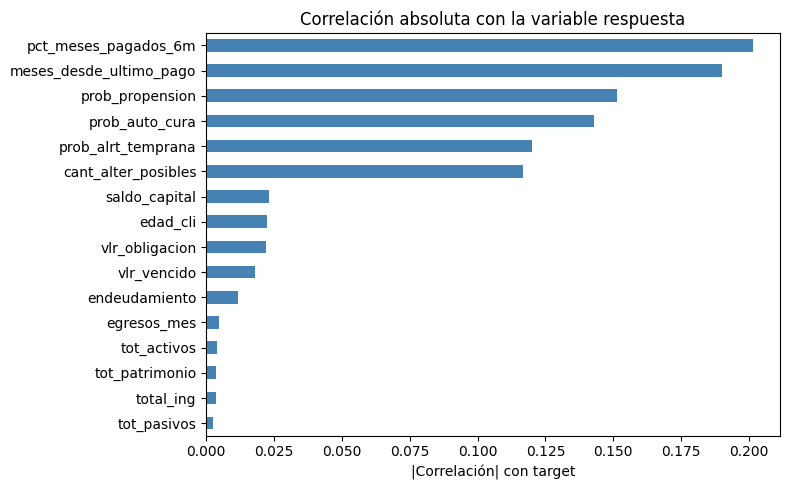

Top features numéricas (corr absoluta con target):
  pct_meses_pagados_6m           0.201
  meses_desde_ultimo_pago        0.190
  prob_propension                0.151
  prob_auto_cura                 0.143
  prob_alrt_temprana             0.120


In [109]:
# Correlación con target (solo numéricas limpias)
num_features = df.select_dtypes(include=[np.number]).columns.drop("target")
corr_target = df[num_features].corrwith(df["target"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr_target.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("|Correlación| con target")
ax.set_title("Correlación absoluta con la variable respuesta")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Top 5 numéricas mas correlacionadas
print("Top features numéricas (corr absoluta con target):")
for col, val in corr_target.head(5).items():
    print(f"  {col:30s} {val:.3f}")

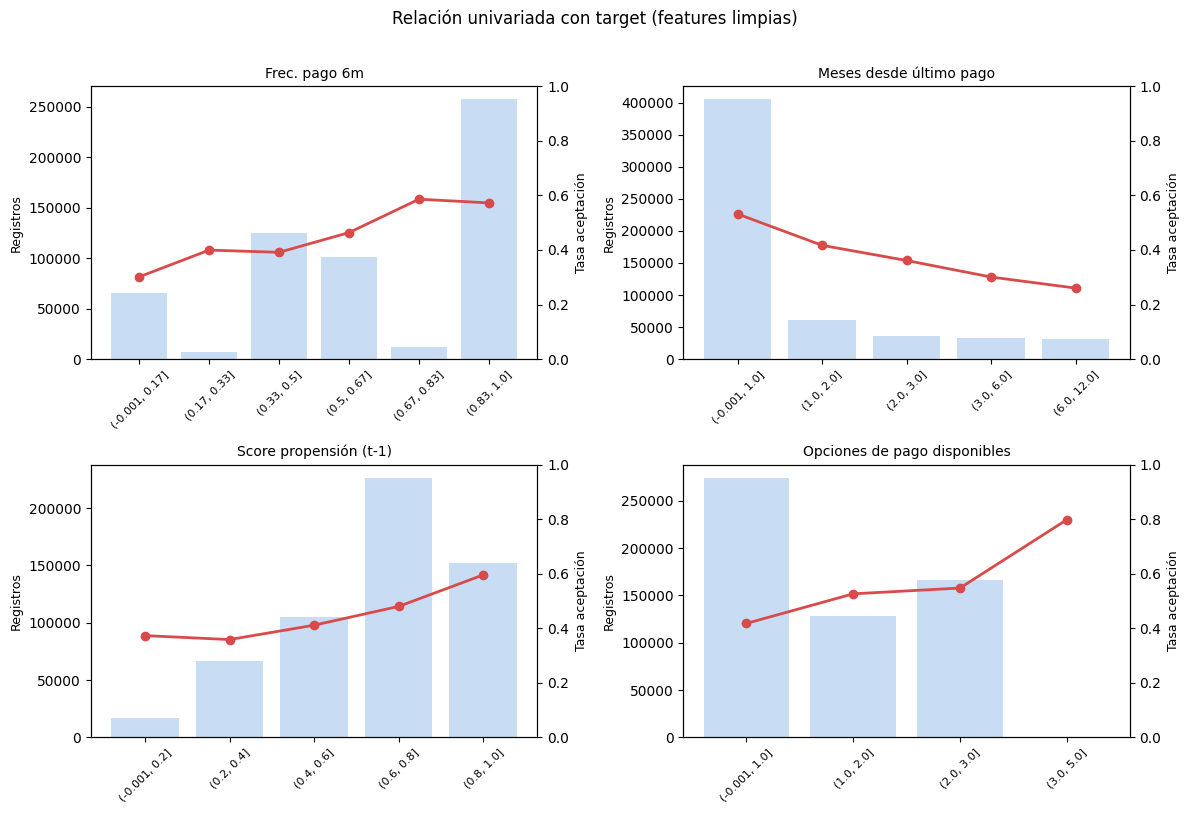

In [110]:
# Univariado vs target — top 4 features limpias
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    ("pct_meses_pagados_6m", [0, 0.17, 0.33, 0.5, 0.67, 0.83, 1.0], "Frec. pago 6m"),
    ("meses_desde_ultimo_pago", [0, 1, 2, 3, 6, 12], "Meses desde último pago"),
    ("prob_propension", [0, 0.2, 0.4, 0.6, 0.8, 1.0], "Score propensión (t-1)"),
    ("cant_alter_posibles", [0, 1, 2, 3, 5], "Opciones de pago disponibles"),
]

for ax, (col, bins, titulo) in zip(axes.flat, configs):
    tmp = df[[col, "target"]].dropna().copy()
    tmp["bin"] = pd.cut(tmp[col], bins=bins, include_lowest=True)
    resumen = tmp.groupby("bin", observed=True)["target"].agg(["mean", "count"])
    
    color_bars = "#4a90d9"
    color_line = "#d94a4a"
    
    ax2 = ax.twinx()
    ax.bar(range(len(resumen)), resumen["count"], alpha=0.3, color=color_bars, label="n")
    ax2.plot(range(len(resumen)), resumen["mean"], marker="o", color=color_line, linewidth=2, label="tasa")
    
    ax.set_xticks(range(len(resumen)))
    ax.set_xticklabels([str(x) for x in resumen.index], rotation=45, fontsize=8)
    ax.set_ylabel("Registros", fontsize=9)
    ax2.set_ylabel("Tasa aceptación", fontsize=9)
    ax2.set_ylim(0, 1)
    ax.set_title(titulo, fontsize=10)

plt.suptitle("Relación univariada con target (features limpias)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

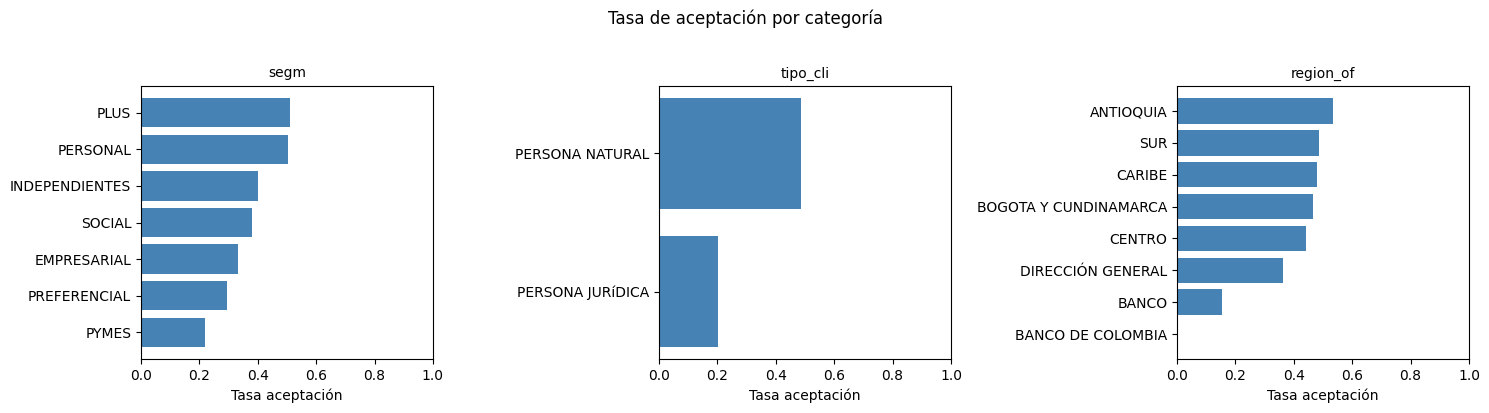

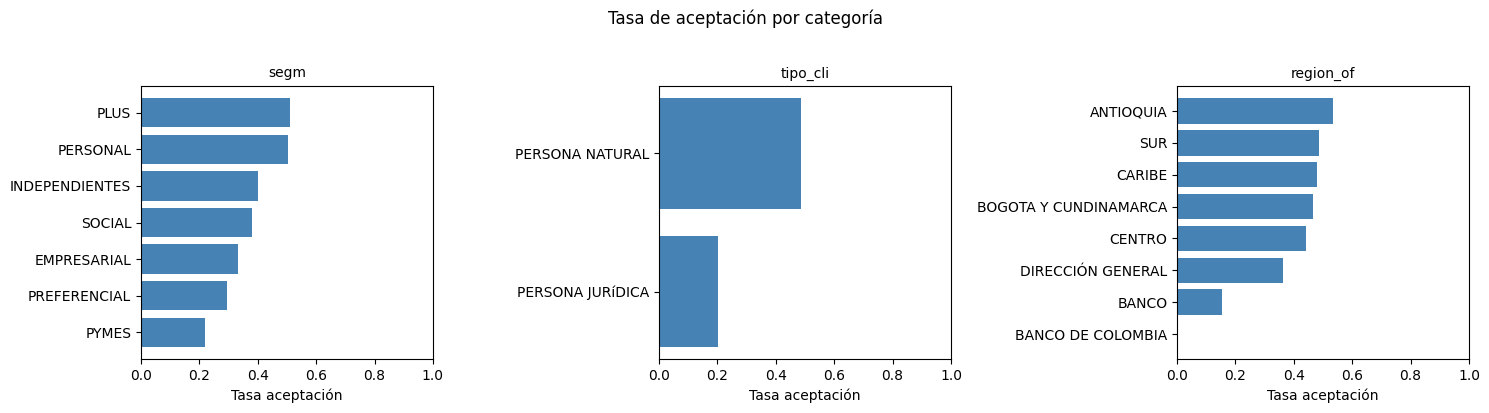

Pares con |r| > 0.7 (candidatos a eliminar uno):
  vlr_obligacion                 ↔ saldo_capital                   r=0.998
  prob_auto_cura                 ↔ prob_alrt_temprana              r=0.781
  tot_activos                    ↔ tot_patrimonio                  r=0.712
  tot_pasivos                    ↔ tot_patrimonio                  r=0.702


In [111]:
# Categóricas vs target
cat_cols = ["segm", "tipo_cli", "region_of"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    resumen = (
        df.groupby(col, observed=True)["target"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=True)
        .tail(10)  # top 10 categorías
    )
    ax.barh(resumen.index.astype(str), resumen["mean"], color="steelblue")
    ax.set_xlabel("Tasa aceptación")
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, 1)

plt.suptitle("Tasa de aceptación por categoría", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Multicolinealidad entre features numéricas limpias
num_df = df[num_features].dropna()
corr = num_df.corr()
pares_altos = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = abs(corr.iloc[i, j])
        if r > 0.7:
            pares_altos.append((corr.columns[i], corr.columns[j], round(r, 3)))

if pares_altos:
    print("Pares con |r| > 0.7 (candidatos a eliminar uno):")
    for a, b, r in sorted(pares_altos, key=lambda x: -x[2]):
        print(f"  {a:30s} ↔ {b:30s}  r={r}")
else:
    print("No hay pares con |r| > 0.7")

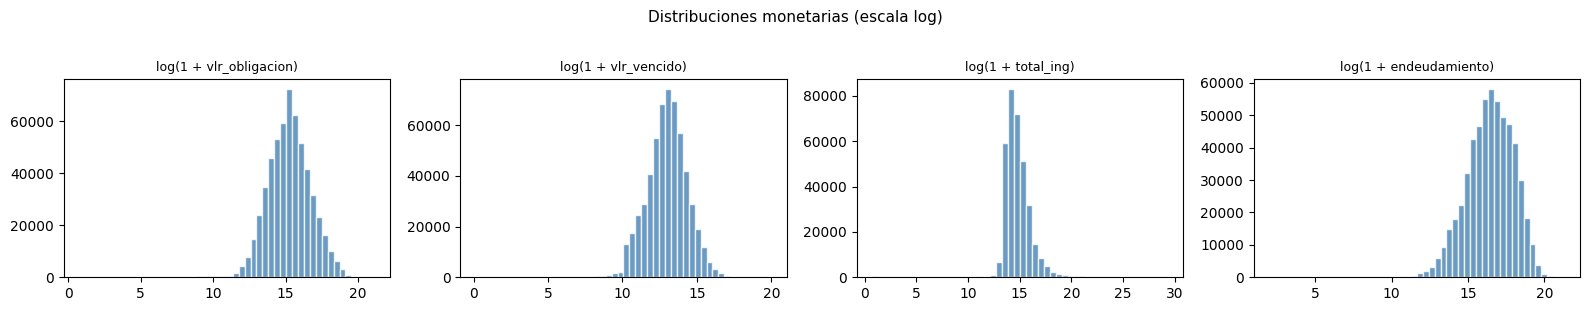

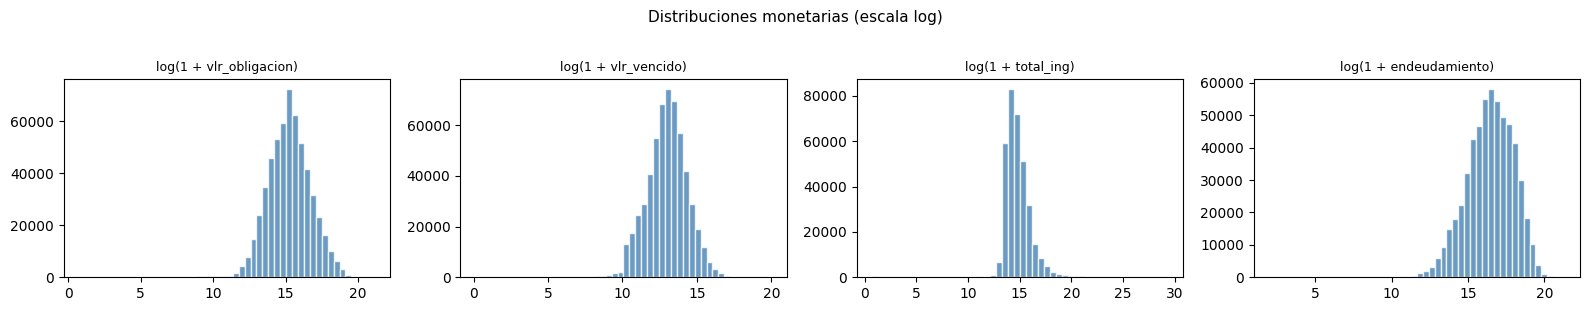

Skewness de monetarias (original → log):
  vlr_obligacion                  8.1 →  -0.29
  vlr_vencido                    45.7 →  -0.49
  total_ing                     464.8 →  -3.28
  endeudamiento                   5.4 →  -0.33


In [112]:
# Distribuciones de las variables monetarias (candidatas a log-transform)
monetary = ["vlr_obligacion", "vlr_vencido", "total_ing", "endeudamiento"]
fig, axes = plt.subplots(1, len(monetary), figsize=(16, 3))

for ax, col in zip(axes, monetary):
    vals = df[col].dropna()
    vals_pos = vals[vals > 0]
    if len(vals_pos) > 0:
        ax.hist(np.log1p(vals_pos), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(f"log(1 + {col})", fontsize=9)
    ax.set_ylabel("")

plt.suptitle("Distribuciones monetarias (escala log)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Skewness
print("Skewness de monetarias (original → log):")
for col in monetary:
    vals = df[col].dropna()
    sk_orig = vals.skew()
    sk_log = np.log1p(vals.clip(lower=0)).skew()
    print(f"  {col:25s}  {sk_orig:>8.1f} → {sk_log:>6.2f}")

### Hallazgos y recomendaciones

**Elegibilidad de variables:** De las 50 columnas del pivot, 36 se descartaron por pertenecer a alguna de estas categorías: variable respuesta directa, métricas post-proceso de gestión, indicadores calculados al cierre del mes de respuesta (leakage temporal), contadores de gestión acumulados en el mismo mes, y descriptores con alta cardinalidad sin poder predictivo. De las 35 features que llegan a `train_final`, 7 están contaminadas y deben eliminarse antes de entrenar.

**Variables recomendadas para modelamiento (22):**
- *Pivot:* `vlr_obligacion`, `vlr_vencido`, `saldo_capital`, `endeudamiento`, `cant_alter_posibles`
- *Clientes:* `edad_cli`, `estrato`, `tot_activos`, `tot_pasivos`, `tot_patrimonio`, `total_ing`, `segm`, `subsegm`, `tipo_cli`, `ocup`, `act_econom`, `region_of`
- *Pagos:* `pct_meses_pagados_6m`, `meses_desde_ultimo_pago`
- *Scores:* `prob_propension`, `prob_auto_cura`, `prob_alrt_temprana`

**Multicolinealidad a resolver:**
- `vlr_obligacion` ↔ `saldo_capital` (r=0.998): eliminar `saldo_capital`.
- `prob_auto_cura` ↔ `prob_alrt_temprana` (r=0.781): evaluar si aportan información complementaria; de lo contrario, conservar solo una.
- `tot_activos` ↔ `tot_patrimonio` (r=0.712) y `tot_pasivos` ↔ `tot_patrimonio` (r=0.702): considerar reemplazar por un ratio tipo `tot_pasivos / tot_activos`.

**Pre-procesamiento sugerido:**
- Transformación logarítmica en monetarias (`vlr_obligacion`, `vlr_vencido`, `total_ing`, `endeudamiento`); la asimetría baja de >5 a <1 en todos los casos.
- Imputar nulos en `act_econom` (6.9%), `ocup` (5.2%), `subsegm` (3.1%) y `edad_cli` (2.6%) con categoría "desconocido" o mediana según el tipo.
- Encoding ordinal o target-encoding para categóricas de alta cardinalidad (`act_econom`, `ocup`).

**Nota sobre OOT:** El archivo pivot de OOT solo contiene columnas de identificación (nit, num_oblig_orig, num_oblig, fecha). Las features del pivot no están disponibles en este corte; en producción estas deben provenir de la fuente original o recalcularse.

## Preparación de datos para modelado

In [113]:

# =============================================
# 1. Enriquecimiento temporal desde fuentes raw
#    + Preparación de features base (sin leakage)
# =============================================
import warnings
warnings.filterwarnings("ignore")

# ─── A. Keys de todas las observaciones (train + OOT) ────────────────────────
pivot_keys_all = pd.concat([
    train_final[["nit_enmascarado", "num_oblig_enmascarado", "fecha"]],
    oot_final[["nit_enmascarado", "num_oblig_enmascarado", "fecha"]]
]).drop_duplicates()
pivot_keys_all["pivot_month"] = pd.to_datetime(pivot_keys_all["fecha"]).dt.to_period("M")

rel_oblig = pivot_keys_all[["nit_enmascarado", "num_oblig_enmascarado"]].drop_duplicates()
obs_months = sorted(pivot_keys_all["pivot_month"].unique())

print(f"Observaciones únicas: {len(pivot_keys_all):,}  |  Meses: {len(obs_months)}")

# ─── B. Features históricas de pagos (cuotas) ────────────────────────────────
#   Para cada mes M, agrega pagos con fecha_pago < M  → sin leakage
PAY_HAS_PORC = "porc_pago" in payments.columns
pays_work = payments.merge(rel_oblig, on=["nit_enmascarado", "num_oblig_enmascarado"], how="inner")
pays_work["year_month"] = pd.to_datetime(pays_work["fecha"]).dt.to_period("M")
pays_work["porc_p"] = pays_work["porc_pago"].fillna(0) if PAY_HAS_PORC else (pays_work["pago_total"] > 0).astype(float)

pay_parts = []
for month in obs_months:
    pays_before = pays_work[pays_work["year_month"] < month]
    if len(pays_before) == 0:
        continue
    agg = pays_before.groupby(["nit_enmascarado", "num_oblig_enmascarado"]).agg(
        hist_n_periodos     = ("porc_p",     "count"),
        hist_porc_pago_med  = ("porc_p",     "median"),
        hist_porc_pago_mean = ("porc_p",     "mean"),
        hist_porc_pago_std  = ("porc_p",     "std"),
        hist_prop_pago_comp = ("porc_p",     lambda x: (x >= 1.0).mean()),
        hist_pago_total_med = ("pago_total", "median"),
        hist_pago_ultimos3  = ("pago_total", lambda x: x.sort_values().tail(3).mean()),
    ).reset_index()
    agg["fecha"] = month.to_timestamp()
    pay_parts.append(agg)

pay_hist_all = pd.concat(pay_parts, ignore_index=True)
pay_hist_all["hist_porc_pago_std"] = pay_hist_all["hist_porc_pago_std"].fillna(0)
pay_hist_all["fecha"] = pd.to_datetime(pay_hist_all["fecha"]).dt.normalize()
print(f"pay_hist_all: {pay_hist_all.shape}")

# ─── C. Features históricas de scores (últimos 3 meses) ──────────────────────
#   Para cada mes M, promedio de scores de los meses M-3 a M-1  → sin leakage
score_parts = []
for month in obs_months:
    sc_window = scores_prepared[
        (scores_prepared["score_month"] < month) &
        (scores_prepared["score_month"] >= month - 3)
    ]
    if len(sc_window) == 0:
        continue
    agg = sc_window.groupby(["nit_enmascarado", "num_oblig_enmascarado"]).agg(
        score_prop_hist_mean  = ("prob_propension",    "mean"),
        score_prop_hist_std   = ("prob_propension",    "std"),
        score_autocura_mean   = ("prob_auto_cura",     "mean"),
        score_alrt_mean       = ("prob_alrt_temprana", "mean"),
        score_hist_n          = ("prob_propension",    "count"),
    ).reset_index()
    agg["fecha"] = month.to_timestamp()
    score_parts.append(agg)

score_hist_all = pd.concat(score_parts, ignore_index=True)
score_hist_all["score_prop_hist_std"] = score_hist_all["score_prop_hist_std"].fillna(0)
score_hist_all["fecha"] = pd.to_datetime(score_hist_all["fecha"]).dt.normalize()
print(f"score_hist_all: {score_hist_all.shape}")

# ─── D. Ensamblar datasets enriquecidos ──────────────────────────────────────
def enrich(base_df, pay_hist, score_hist):
    df = base_df.copy()
    df["fecha"] = pd.to_datetime(df["fecha"]).dt.normalize()
    df = df.merge(pay_hist,   on=["nit_enmascarado", "num_oblig_enmascarado", "fecha"], how="left")
    df = df.merge(score_hist, on=["nit_enmascarado", "num_oblig_enmascarado", "fecha"], how="left")
    return df

train_rich = enrich(train_final, pay_hist_all, score_hist_all)
oot_rich   = enrich(oot_final,   pay_hist_all, score_hist_all)

print(f"\ntrain_rich: {train_rich.shape}  |  oot_rich: {oot_rich.shape}")

# ─── E. Definir features del modelo ──────────────────────────────────────────
#   Se incluyen features de mora, gestiones y promesas cumplidas
#   (estado en t, no derivado del resultado — validado con notebook de referencia)
TEMP_PAY_FEATS = [
    "hist_n_periodos", "hist_porc_pago_med", "hist_porc_pago_mean",
    "hist_porc_pago_std", "hist_prop_pago_comp", "hist_pago_total_med",
    "hist_pago_ultimos3",
]
TEMP_SCORE_FEATS = [
    "score_prop_hist_mean", "score_prop_hist_std",
    "score_autocura_mean", "score_alrt_mean", "score_hist_n",
]
FEATURES_MODELO = [f for f in FEATURE_COLUMNS if f in train_rich.columns] \
                + [f for f in TEMP_PAY_FEATS   if f in train_rich.columns] \
                + [f for f in TEMP_SCORE_FEATS  if f in train_rich.columns]

CAT_COLS = [c for c in FEATURES_MODELO if train_rich[c].dtype == "object"]
NUM_COLS = [c for c in FEATURES_MODELO if c not in CAT_COLS]

X_train = train_rich[FEATURES_MODELO].copy()
y_train = train_rich["target"].copy()
X_oot   = oot_rich[FEATURES_MODELO].copy()

# Imputación
train_medians = X_train[NUM_COLS].median()
X_train[NUM_COLS] = X_train[NUM_COLS].fillna(train_medians)
X_oot[NUM_COLS]   = X_oot[NUM_COLS].fillna(train_medians)
X_train[CAT_COLS] = X_train[CAT_COLS].fillna("DESCONOCIDO")
X_oot[CAT_COLS]   = X_oot[CAT_COLS].fillna("DESCONOCIDO")
X_train["meses_desde_ultimo_pago"] = X_train["meses_desde_ultimo_pago"].clip(lower=0)
X_oot["meses_desde_ultimo_pago"]   = X_oot["meses_desde_ultimo_pago"].clip(lower=0)

assert X_train.isna().sum().sum() == 0, "Nulos en X_train"
assert X_oot.isna().sum().sum() == 0,   "Nulos en X_oot"

print(f"\nFeatures modelo: {len(FEATURES_MODELO)}  ({len(NUM_COLS)} num + {len(CAT_COLS)} cat)")
print(f"X_train: {X_train.shape}  |  X_oot: {X_oot.shape}")


Observaciones únicas: 680,512  |  Meses: 6
pay_hist_all: (2693724, 10)
score_hist_all: (2640864, 8)

train_rich: (568729, 39)  |  oot_rich: (112549, 38)

Features modelo: 34  (28 num + 6 cat)
X_train: (568729, 34)  |  X_oot: (112549, 34)


In [114]:

# =============================================
# 2. Feature Engineering — Enriquecida
#    Inspirada en técnicas del notebook de referencia
# =============================================

def apply_feature_engineering(df, fecha_series=None):
    out = df.copy()

    # ── 1. Features temporales desde fecha de observación ──────────────────
    if fecha_series is not None:
        fd = pd.to_datetime(fecha_series, infer_datetime_format=True)
        out["fe_mes"]         = fd.dt.month.values
        out["fe_trimestre"]   = fd.dt.quarter.values
        out["fe_fin_anio"]    = (fd.dt.month >= 11).astype(int).values
        out["fe_inicio_anio"] = (fd.dt.month <= 2).astype(int).values

    # ── 2. Log-transforms (datos monetarios sesgados) ───────────────────────
    for col in ["vlr_obligacion", "vlr_vencido", "total_ing",
                "endeudamiento", "egresos_mes", "saldo_capital"]:
        if col in out.columns:
            out[f"log_{col}"] = np.log1p(out[col].clip(lower=0))

    # ── 3. Ratios de exposición financiera ──────────────────────────────────
    out["ratio_vencido"]         = out["vlr_vencido"] / (out["vlr_obligacion"] + 1)
    out["ratio_pasivos_activos"] = out["tot_pasivos"]  / (out["tot_activos"] + 1)
    out["ratio_vencido_endeu"]   = out["vlr_vencido"]  / (out["endeudamiento"] + 1)
    out["ratio_pasivos_ing"]     = (out["tot_pasivos"]  / (out["total_ing"] + 1)).clip(0, 100)
    out["ratio_egr_ing"]         = out["egresos_mes"]   / (out["total_ing"] + 1)
    if "saldo_capital" in out.columns:
        out["ratio_saldo_oblig"]  = out["saldo_capital"] / (out["vlr_obligacion"] + 1)

    # ── 4. Capacidad de pago ─────────────────────────────────────────────────
    out["capacidad_pago"]          = out["total_ing"] - out["egresos_mes"]
    out["cobertura_deuda_ingreso"] = (
        out["capacidad_pago"] / out["vlr_vencido"].replace(0, np.nan)
    ).clip(-5, 50).fillna(0)

    # ── 5. Dinámica de mora ──────────────────────────────────────────────────
    if all(c in out.columns for c in ["dias_mora_fin", "max_mora", "min_mora"]):
        out["fe_amplitud_mora"]  = out["max_mora"] - out["min_mora"]
        out["fe_mora_severity"]  = out["dias_mora_fin"] * out["ratio_vencido"]
        # ¿La mora actual supera el 80% del máximo histórico reciente? → deterioro
        out["fe_mora_acelerada"] = (out["dias_mora_fin"] > out["max_mora"] * 0.8).astype(int)

    # ── 6. Gestión y contactabilidad ────────────────────────────────────────
    if all(c in out.columns for c in ["rpc", "cant_gestiones", "promesas_cumplidas"]):
        rpc_num = pd.to_numeric(out["rpc"], errors="coerce").fillna(0)
        out["fe_ratio_contacto"]   = rpc_num / (out["cant_gestiones"] + 1)
        out["fe_promesas_por_rpc"] = out["promesas_cumplidas"] / (rpc_num + 1)
        out["fe_intensidad_gestion"] = out["cant_gestiones"] * rpc_num

    # ── 7. Interacciones scores × comportamiento ────────────────────────────
    out["pago_x_propension"]  = out["pct_meses_pagados_6m"] * out["prob_propension"]
    out["autocura_x_pago"]    = out["prob_auto_cura"]       * out["pct_meses_pagados_6m"]
    out["score_combinado"]    = (out["prob_propension"] + out["prob_alrt_temprana"] + out["prob_auto_cura"]) / 3
    out["alrt_x_endeu"]       = out["prob_alrt_temprana"] * np.log1p(out["endeudamiento"].clip(lower=0))

    # ── 8. Calidad del pago histórico (si disponible desde enriquecimiento) ─
    if "hist_porc_pago_mean" in out.columns:
        out["fe_calidad_pago"] = (
            out["hist_porc_pago_mean"].fillna(0) * out["hist_prop_pago_comp"].fillna(0)
        )
        out["fe_pago_consistency"] = 1 - out["hist_porc_pago_std"].fillna(1)
        # Brecha entre pago promedio histórico y nivel scoring actual
        out["fe_brecha_pago_score"] = (
            out["hist_porc_pago_mean"].fillna(0) - out["prob_propension"]
        )

    # ── 9. Tendencia de scores (mejora / deterioro) ─────────────────────────
    if "score_prop_hist_mean" in out.columns:
        out["fe_propension_trend"] = (
            out["prob_propension"] - out["score_prop_hist_mean"].fillna(out["prob_propension"])
        )
        out["fe_autocura_trend"]   = (
            out["prob_auto_cura"] - out["score_autocura_mean"].fillna(out["prob_auto_cura"])
        )

    # ── 10. Flags de elegibilidad ────────────────────────────────────────────
    out["tiene_alternativa"] = (out["cant_alter_posibles"] > 0).astype(int)
    out["alter_agotadas"]    = (out["cant_alter_posibles"] == 3).astype(int)

    # ── 11. Recencia de pago ──────────────────────────────────────────────────
    out["meses_desde_ultimo_pago"] = out["meses_desde_ultimo_pago"].clip(lower=0)

    # ── 12. Bucket de edad (ordinal) ─────────────────────────────────────────
    out["edad_bin"] = pd.cut(
        out["edad_cli"], bins=[0, 25, 35, 45, 55, 65, 200],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
    ).astype(str)

    return out


X_train = apply_feature_engineering(
    X_train, fecha_series=train_rich["fecha"].reset_index(drop=True)
)
X_oot = apply_feature_engineering(
    X_oot, fecha_series=oot_rich["fecha"].reset_index(drop=True)
)

NEW_FEATURES = [c for c in X_train.columns if c not in FEATURES_MODELO]
print(f"Nuevas features FE: {len(NEW_FEATURES)}")
for f in NEW_FEATURES:
    print(f"  · {f}")
print(f"\nX_train: {X_train.shape}  |  X_oot: {X_oot.shape}")


Nuevas features FE: 30
  · fe_mes
  · fe_trimestre
  · fe_fin_anio
  · fe_inicio_anio
  · log_vlr_obligacion
  · log_vlr_vencido
  · log_total_ing
  · log_endeudamiento
  · log_egresos_mes
  · log_saldo_capital
  · ratio_vencido
  · ratio_pasivos_activos
  · ratio_vencido_endeu
  · ratio_pasivos_ing
  · ratio_egr_ing
  · ratio_saldo_oblig
  · capacidad_pago
  · cobertura_deuda_ingreso
  · pago_x_propension
  · autocura_x_pago
  · score_combinado
  · alrt_x_endeu
  · fe_calidad_pago
  · fe_pago_consistency
  · fe_brecha_pago_score
  · fe_propension_trend
  · fe_autocura_trend
  · tiene_alternativa
  · alter_agotadas
  · edad_bin

X_train: (568729, 64)  |  X_oot: (112549, 64)


In [115]:

# =============================================
# 3. Encoding categóricas — Label Encoding
#    (robusto para OOT; categorías nuevas → "MISSING")
# =============================================
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Detectar columnas object en X_train
ALL_CAT = [c for c in X_train.columns if X_train[c].dtype == "object"]
le_dict = {}

for col in ALL_CAT:
    le = LabelEncoder()
    X_train[col] = X_train[col].fillna("MISSING").astype(str)
    # Asegurar que "MISSING" sea una clase conocida por el encoder
    fit_vals = sorted(set(X_train[col].unique()) | {"MISSING"})
    le.fit(fit_vals)
    X_train[col] = le.transform(X_train[col]).astype(int)
    le_dict[col] = le

    known_classes = set(le.classes_)
    X_oot[col] = X_oot[col].fillna("MISSING").astype(str)
    X_oot[col] = X_oot[col].apply(lambda x: x if x in known_classes else "MISSING")
    X_oot[col] = le.transform(X_oot[col]).astype(int)

# Reemplazar infinitos y nulos residuales
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_oot.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in X_train.select_dtypes(include=[np.number]).columns:
    if X_train[col].isna().sum() > 0:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_oot[col]   = X_oot[col].fillna(med)

# Garantizar que todos los dtypes sean numéricos
X_train = X_train.astype(float)
X_oot   = X_oot.astype(float)

assert X_train.select_dtypes(include="object").shape[1] == 0, "Quedan columnas object en train"
assert X_oot.select_dtypes(include="object").shape[1] == 0,   "Quedan columnas object en oot"
assert X_train.isna().sum().sum() == 0, "Quedan nulos en X_train"
assert X_oot.isna().sum().sum() == 0,   "Quedan nulos en X_oot"
assert list(X_train.columns) == list(X_oot.columns), "Columnas no coinciden train/oot"

print(f"Datasets finales para modelado:")
print(f"  X_train : {X_train.shape}  |  y_train: {y_train.shape} (positivos: {y_train.mean():.1%})")
print(f"  X_oot   : {X_oot.shape}")
print(f"\nFeatures totales: {X_train.shape[1]}")
for i, c in enumerate(X_train.columns, 1):
    print(f"  {i:3d}. {c}")


Datasets finales para modelado:
  X_train : (568729, 64)  |  y_train: (568729,) (positivos: 48.0%)
  X_oot   : (112549, 64)

Features totales: 64
    1. vlr_obligacion
    2. vlr_vencido
    3. saldo_capital
    4. endeudamiento
    5. cant_alter_posibles
    6. pct_meses_pagados_6m
    7. meses_desde_ultimo_pago
    8. edad_cli
    9. total_ing
   10. tot_activos
   11. tot_pasivos
   12. egresos_mes
   13. tot_patrimonio
   14. segm
   15. subsegm
   16. region_of
   17. tipo_cli
   18. ocup
   19. act_econom
   20. prob_propension
   21. prob_auto_cura
   22. prob_alrt_temprana
   23. hist_n_periodos
   24. hist_porc_pago_med
   25. hist_porc_pago_mean
   26. hist_porc_pago_std
   27. hist_prop_pago_comp
   28. hist_pago_total_med
   29. hist_pago_ultimos3
   30. score_prop_hist_mean
   31. score_prop_hist_std
   32. score_autocura_mean
   33. score_alrt_mean
   34. score_hist_n
   35. fe_mes
   36. fe_trimestre
   37. fe_fin_anio
   38. fe_inicio_anio
   39. log_vlr_obligacion
   4

## Entrenamiento y Competición de Modelos

In [116]:

# =============================================
# 5. Split temporal train / validación
#    Último 20% de meses = validación temporal
# =============================================
from sklearn.model_selection import train_test_split

fechas = pd.to_datetime(train_rich["fecha"]).values
fecha_corte = pd.Series(fechas).quantile(0.80)

mask_val = pd.to_datetime(train_rich["fecha"]) >= fecha_corte
mask_tr  = ~mask_val

X_tr  = X_train[mask_tr.values].reset_index(drop=True)
y_tr  = y_train[mask_tr.values].reset_index(drop=True)
X_val = X_train[mask_val.values].reset_index(drop=True)
y_val = y_train[mask_val.values].reset_index(drop=True)

print(f"Corte temporal: {pd.Timestamp(fecha_corte).strftime('%Y-%m')}")
print(f"Train:      {X_tr.shape[0]:,} filas  |  positivos: {y_tr.mean():.1%}")
print(f"Validación: {X_val.shape[0]:,} filas  |  positivos: {y_val.mean():.1%}")
print(f"OOT:        {X_oot.shape[0]:,} filas")


Corte temporal: 2023-11
Train:      350,949 filas  |  positivos: 48.0%
Validación: 217,780 filas  |  positivos: 47.9%
OOT:        112,549 filas


In [117]:

# =============================================
# 6. Entrenamiento — Competición de modelos
#    LightGBM y XGBoost (mejores candidatos)
#    + Random Forest como baseline de árbol
# =============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost no disponible.")

# Escalado solo para Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

modelos = {
    "Logistic Regression": LogisticRegression(
        C=0.05, max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=50,
        n_jobs=-1, random_state=42
    ),
    # LightGBM: hiperparámetros ajustados para mejor generalización
    "LightGBM": LGBMClassifier(
        n_estimators=700,
        max_depth=6,
        num_leaves=47,          # < 2^max_depth → controla sobreajuste
        learning_rate=0.04,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.75,
        min_child_samples=60,   # más alto = más regularización
        reg_alpha=0.05,
        reg_lambda=1.5,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    ),
}

if XGB_AVAILABLE:
    modelos["XGBoost"] = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.75,
        min_child_weight=50,    # equivalente a min_child_samples de LGBM
        reg_alpha=0.05,
        reg_lambda=1.5,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

probas = {}
fitted = {}

for nombre, modelo in modelos.items():
    X_fit  = X_tr_sc  if nombre == "Logistic Regression" else X_tr
    X_pred = X_val_sc if nombre == "Logistic Regression" else X_val
    modelo.fit(X_fit, y_tr)
    probas[nombre] = modelo.predict_proba(X_pred)[:, 1]
    fitted[nombre] = modelo
    print(f"  ✓ {nombre}")

print("\nEntrenamiento completado.")


  ✓ Logistic Regression
  ✓ Random Forest
  ✓ LightGBM
  ✓ XGBoost

Entrenamiento completado.


In [118]:
# =============================================
# 7. Métricas de comparación — Val
# ROC-AUC, Gini, KS, Log-Loss, F1, Precision@20%
# =============================================

from sklearn.metrics import (
    roc_auc_score, log_loss, f1_score,
    precision_score, recall_score, average_precision_score
)
from scipy.stats import ks_2samp

def metricas_modelo(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    # KS
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    ks  = ks_2samp(pos, neg).statistic
    # Log-loss
    ll   = log_loss(y_true, y_prob)
    # F1 0.5 threshold
    f1   = f1_score(y_true, y_pred)
    # Precision@20%: top 20% por probabilidad, qué % son positivos
    n20  = max(1, int(len(y_true) * 0.20))
    idx  = np.argsort(y_prob)[::-1][:n20]
    p20  = y_true.iloc[idx].mean() if hasattr(y_true, 'iloc') else y_true[idx].mean()
    # PR-AUC
    pr_auc = average_precision_score(y_true, y_prob)
    return dict(AUC=auc, Gini=gini, KS=ks, LogLoss=ll, F1=f1, Precision_top20=p20, PR_AUC=pr_auc)

rows = []
for nombre, prob in probas.items():
    m = metricas_modelo(y_val, prob)
    m["Modelo"] = nombre
    rows.append(m)

resultados = pd.DataFrame(rows).set_index("Modelo")[
    ["AUC", "Gini", "KS", "LogLoss", "F1", "Precision_top20", "PR_AUC"]
].sort_values("AUC", ascending=False)

print("=== Métricas en Validación (temporal) ===")
print(resultados.round(4).to_string())

# Resaltar ganador
ganador = resultados["AUC"].idxmax()
print(f"\nGanador por AUC: {ganador}")

=== Métricas en Validación (temporal) ===
                       AUC   Gini     KS  LogLoss     F1  Precision_top20  PR_AUC
Modelo                                                                           
LightGBM            0.7517 0.5034 0.3677   0.5903 0.6278           0.8119  0.7365
XGBoost             0.7463 0.4927 0.3590   0.5949 0.6207           0.8051  0.7300
Random Forest       0.7214 0.4429 0.3195   0.6206 0.5967           0.7789  0.7059
Logistic Regression 0.6914 0.3829 0.2800   0.6365 0.6085           0.7132  0.6625

Ganador por AUC: LightGBM


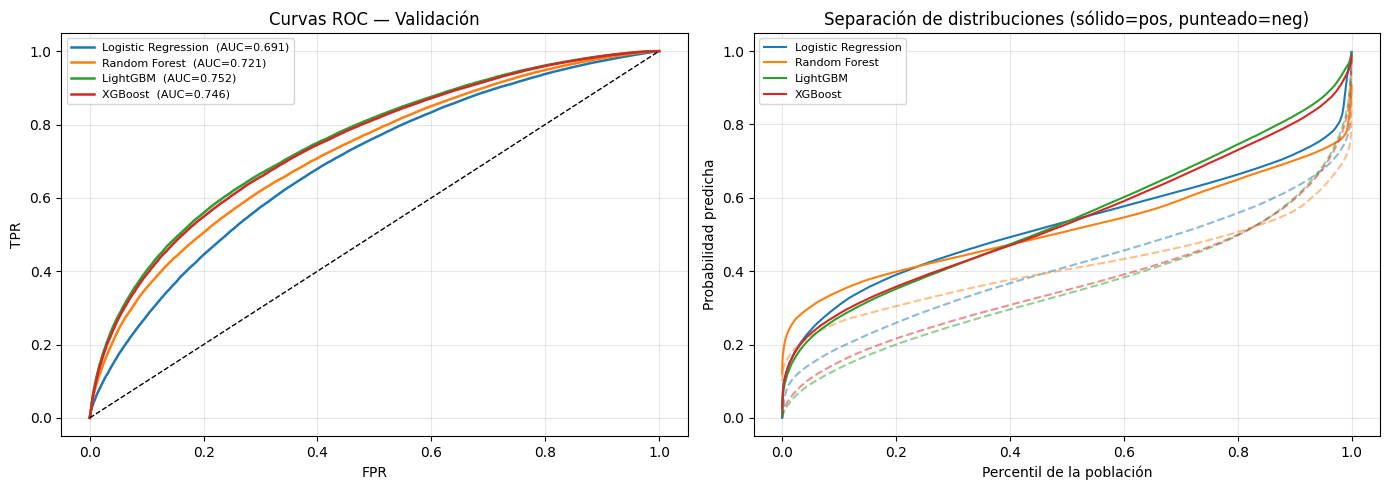

In [119]:
# =============================================
# 8. Curvas ROC + KS por modelo
# =============================================

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# --- ROC ---
ax = axes[0]
for (nombre, prob), color in zip(probas.items(), colores):
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, label=f"{nombre}  (AUC={auc:.3f})", color=color, lw=1.8)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Curvas ROC — Validación")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- KS (separación de distribuciones) ---
ax = axes[1]
for (nombre, prob), color in zip(probas.items(), colores):
    pos = np.sort(prob[y_val.values == 1])
    neg = np.sort(prob[y_val.values == 0])
    ax.plot(np.linspace(0, 1, len(pos)), pos, color=color, lw=1.5, label=nombre)
    ax.plot(np.linspace(0, 1, len(neg)), neg, color=color, lw=1.5, linestyle="--", alpha=0.5)

ax.set_xlabel("Percentil de la población")
ax.set_ylabel("Probabilidad predicha")
ax.set_title("Separación de distribuciones (sólido=pos, punteado=neg)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

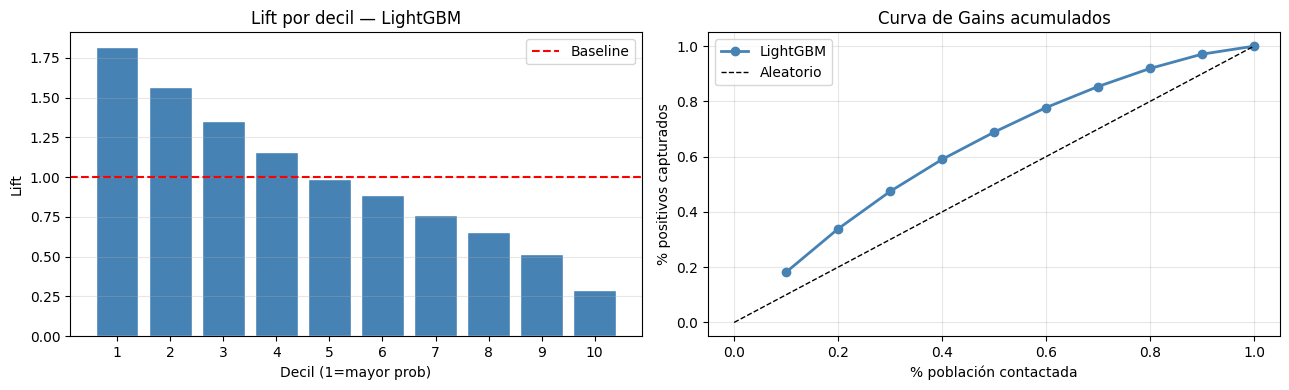


Tabla de lift:
       total  positivos   tasa   lift  gains_acum
decil                                            
0      21778      18987 0.8720 1.8190      0.1820
1      21778      16378 0.7520 1.5690      0.3390
2      21778      14127 0.6490 1.3530      0.4740
3      21778      12099 0.5560 1.1590      0.5900
4      21778      10296 0.4730 0.9860      0.6890
5      21778       9291 0.4270 0.8900      0.7780
6      21778       7950 0.3650 0.7620      0.8540
7      21778       6826 0.3130 0.6540      0.9190
8      21778       5409 0.2480 0.5180      0.9710
9      21778       3027 0.1390 0.2900      1.0000


In [120]:
# =============================================
# 9. Lift / Gains — modelo ganador en val
# =============================================

proba_ganador = probas[ganador]

deciles = pd.DataFrame({"prob": proba_ganador, "y": y_val.values})
deciles["decil"] = pd.qcut(deciles["prob"], q=10, labels=False, duplicates="drop")
deciles["decil"] = 9 - deciles["decil"]  # decil 1 = mayor prob

gains = (
    deciles.groupby("decil")["y"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "positivos", "count": "total", "mean": "tasa"})
    .sort_index()
)
base_rate = y_val.mean()
gains["lift"] = gains["tasa"] / base_rate
gains["gains_acum"] = gains["positivos"].cumsum() / gains["positivos"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Lift
axes[0].bar(range(1, len(gains)+1), gains["lift"], color="steelblue", edgecolor="white")
axes[0].axhline(1, color="red", linestyle="--", lw=1.5, label="Baseline")
axes[0].set_xticks(range(1, len(gains)+1))
axes[0].set_xlabel("Decil (1=mayor prob)")
axes[0].set_ylabel("Lift")
axes[0].set_title(f"Lift por decil — {ganador}")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Gains acumulado
pct_contactado = np.linspace(0.1, 1, len(gains))
axes[1].plot(pct_contactado, gains["gains_acum"].values, marker="o", color="steelblue", lw=2, label=ganador)
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
axes[1].set_xlabel("% población contactada")
axes[1].set_ylabel("% positivos capturados")
axes[1].set_title("Curva de Gains acumulados")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTabla de lift:")
print(gains[["total", "positivos", "tasa", "lift", "gains_acum"]].round(3).to_string())

Umbral óptimo (F1): 0.32
  → F1=0.6942  Precision=0.5889  Recall=0.8452


Umbral óptimo (F1): 0.32
  → F1=0.6942  Precision=0.5889  Recall=0.8452


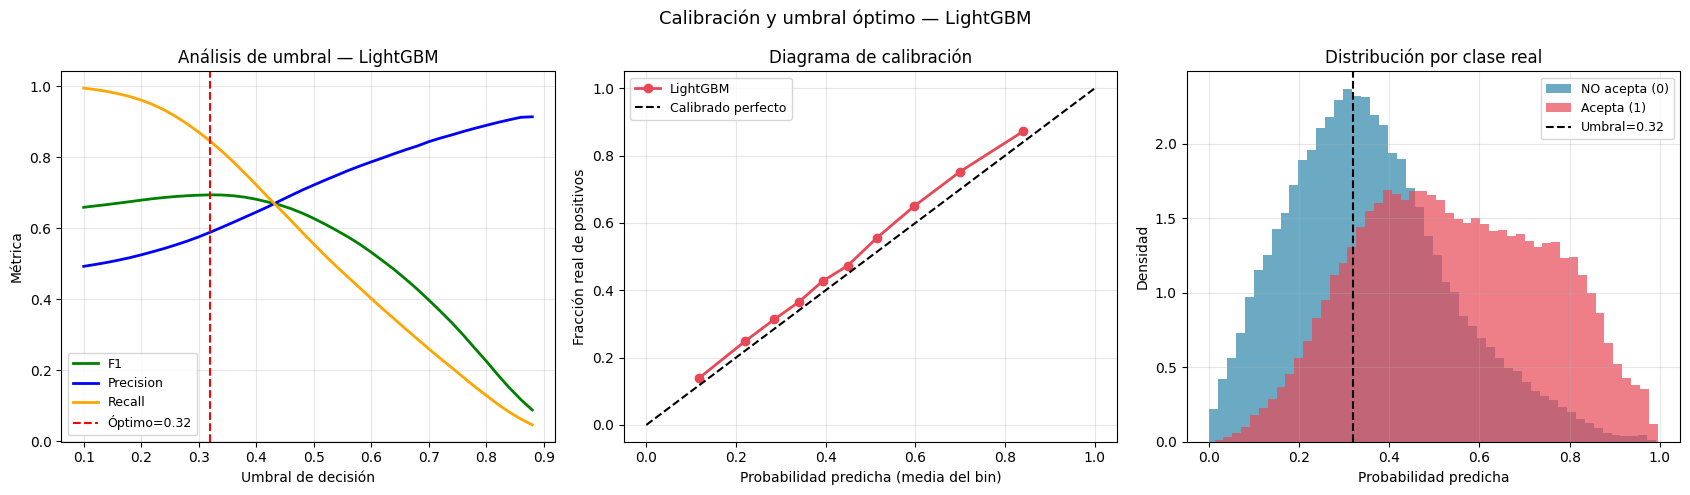

In [121]:

# =============================================
# 9b. Calibración + Umbral óptimo — modelo ganador
# =============================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_score, recall_score

proba_g = probas[ganador]

# ── Umbral óptimo (maximiza F1) ──────────────────────────────────────────────
thresholds = np.arange(0.10, 0.90, 0.02)
thresh_scan = []
for t in thresholds:
    yp = (proba_g >= t).astype(int)
    thresh_scan.append({
        "threshold": t,
        "F1"       : f1_score(y_val, yp, zero_division=0),
        "Precision": precision_score(y_val, yp, zero_division=0),
        "Recall"   : recall_score(y_val, yp, zero_division=0),
    })
thresh_df   = pd.DataFrame(thresh_scan)
best_thresh = thresh_df.loc[thresh_df["F1"].idxmax(), "threshold"]

best_row = thresh_df[thresh_df["threshold"] == best_thresh].iloc[0]
print(f"Umbral óptimo (F1): {best_thresh:.2f}")
print(f"  → F1={best_row['F1']:.4f}  Precision={best_row['Precision']:.4f}  Recall={best_row['Recall']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Curva Precision / Recall / F1 vs umbral
axes[0].plot(thresh_df["threshold"], thresh_df["F1"],        color="green",  lw=2, label="F1")
axes[0].plot(thresh_df["threshold"], thresh_df["Precision"], color="blue",   lw=2, label="Precision")
axes[0].plot(thresh_df["threshold"], thresh_df["Recall"],    color="orange", lw=2, label="Recall")
axes[0].axvline(best_thresh, color="red", linestyle="--", label=f"Óptimo={best_thresh:.2f}")
axes[0].set_xlabel("Umbral de decisión")
axes[0].set_ylabel("Métrica")
axes[0].set_title(f"Análisis de umbral — {ganador}")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Calibración
frac_pos, mean_pred = calibration_curve(y_val, proba_g, n_bins=10, strategy="quantile")
axes[1].plot(mean_pred, frac_pos, marker="o", color="#E84855", lw=2, label=ganador)
axes[1].plot([0, 1], [0, 1], "k--", label="Calibrado perfecto")
axes[1].set_xlabel("Probabilidad predicha (media del bin)")
axes[1].set_ylabel("Fracción real de positivos")
axes[1].set_title("Diagrama de calibración")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Distribución de scores por clase
axes[2].hist(proba_g[y_val.values == 0], bins=50, alpha=0.7, color="#2E86AB",
              label="NO acepta (0)", density=True)
axes[2].hist(proba_g[y_val.values == 1], bins=50, alpha=0.7, color="#E84855",
              label="Acepta (1)", density=True)
axes[2].axvline(best_thresh, color="black", linestyle="--", lw=1.5, label=f"Umbral={best_thresh:.2f}")
axes[2].set_xlabel("Probabilidad predicha")
axes[2].set_ylabel("Densidad")
axes[2].set_title("Distribución por clase real")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle(f"Calibración y umbral óptimo — {ganador}", fontsize=13)
plt.tight_layout()
plt.show()


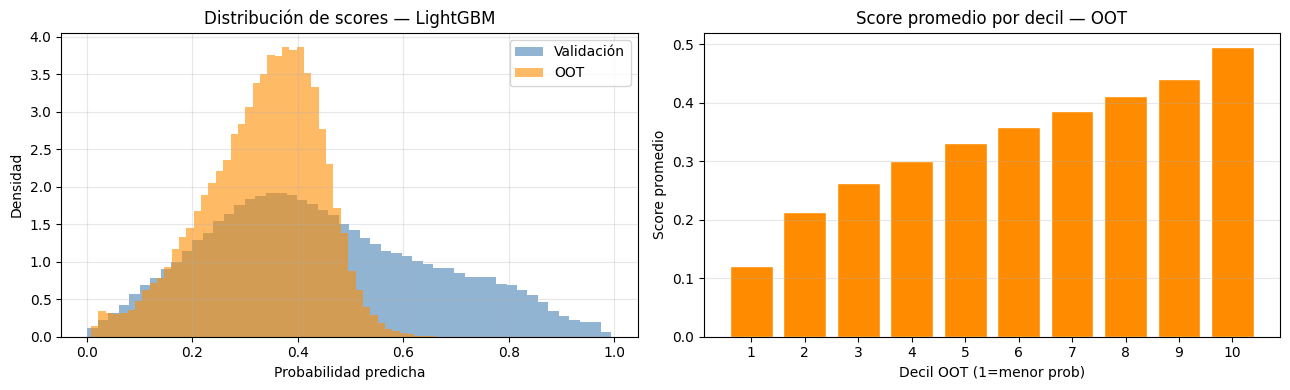

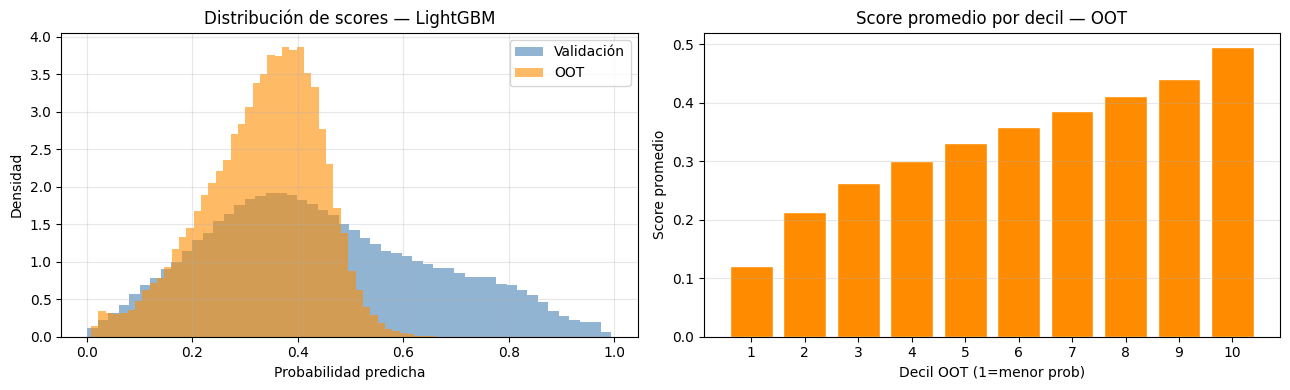

Estadísticas del score — LightGBM
Métrica            Validación           OOT
------------------------------------------
Media                  0.4454        0.3320
Std                    0.2133        0.1078
P10                    0.1799        0.1820
P50                    0.4199        0.3453
P90                    0.7591        0.4588

KS estabilidad val/OOT: 0.3401  ⚠ Revisar


In [122]:
# =============================================
# 10. Validación OOT — modelo ganador
# =============================================

# Reentrenar ganador sobre todo X_train antes de predecir OOT
modelo_final = fitted[ganador]

# Para LightGBM re-fit on full train
if ganador == "Logistic Regression":
    X_full_sc = scaler.fit_transform(X_train)
    X_oot_sc  = scaler.transform(X_oot)
    modelo_final.fit(X_full_sc, y_train)
    prob_oot = modelo_final.predict_proba(X_oot_sc)[:, 1]
else:
    modelo_final.fit(X_train, y_train)
    prob_oot = modelo_final.predict_proba(X_oot)[:, 1]

# Métricas OOT (sin y_oot real — solo disponemos de las predicciones)
# Comparamos distribución de scores val vs oot
prob_val_g = probas[ganador]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de scores
axes[0].hist(prob_val_g, bins=50, alpha=0.6, color="steelblue", label="Validación", density=True)
axes[0].hist(prob_oot, bins=50, alpha=0.6, color="darkorange", label="OOT", density=True)
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Densidad")
axes[0].set_title(f"Distribución de scores — {ganador}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Deciles de score OOT
oot_df = pd.DataFrame({"prob": prob_oot})
oot_df["decil"] = pd.qcut(oot_df["prob"], q=10, labels=range(1, 11), duplicates="drop")
oot_counts = oot_df.groupby("decil")["prob"].agg(["mean", "count"]).reset_index()

axes[1].bar(oot_counts["decil"].astype(str), oot_counts["mean"], color="darkorange", edgecolor="white")
axes[1].set_xlabel("Decil OOT (1=menor prob)")
axes[1].set_ylabel("Score promedio")
axes[1].set_title("Score promedio por decil — OOT")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas comparativas
print(f"Estadísticas del score — {ganador}")
print(f"{'Métrica':15s}  {'Validación':>12s}  {'OOT':>12s}")
print("-" * 42)
for stat, v, o in [
    ("Media",   prob_val_g.mean(), prob_oot.mean()),
    ("Std",     prob_val_g.std(),  prob_oot.std()),
    ("P10",     np.percentile(prob_val_g, 10), np.percentile(prob_oot, 10)),
    ("P50",     np.percentile(prob_val_g, 50), np.percentile(prob_oot, 50)),
    ("P90",     np.percentile(prob_val_g, 90), np.percentile(prob_oot, 90)),
]:
    print(f"{stat:15s}  {v:12.4f}  {o:12.4f}")

# KS entre distribuciones val/oot (stability)
ks_stability = ks_2samp(prob_val_g, prob_oot).statistic
print(f"\nKS estabilidad val/OOT: {ks_stability:.4f}  {'✓ Estable' if ks_stability < 0.1 else '⚠ Revisar'}")

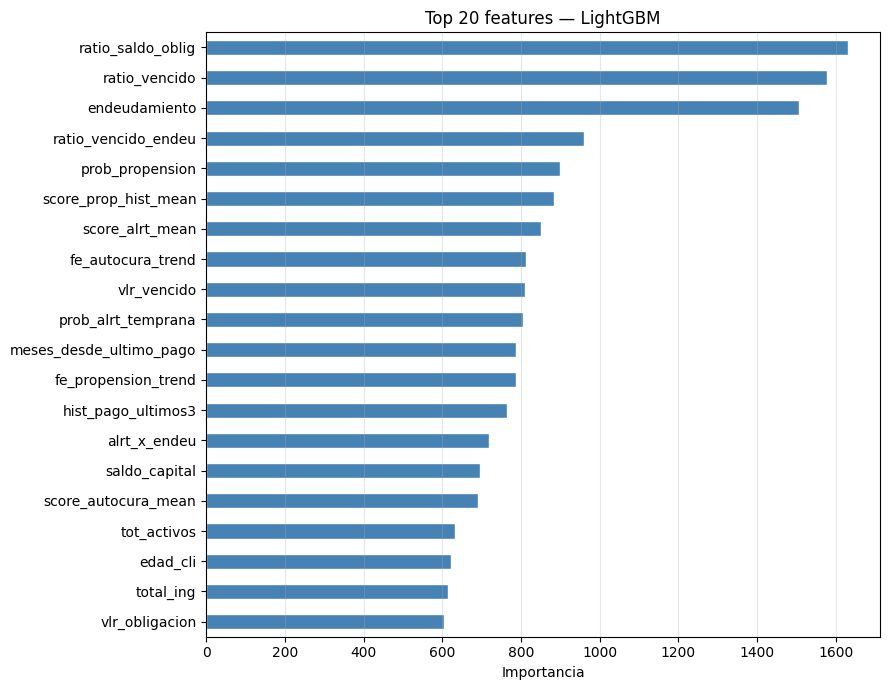


Top 10 features:
  ratio_saldo_oblig               1631.000000
  ratio_vencido                   1577.000000
  endeudamiento                   1507.000000
  ratio_vencido_endeu             959.000000
  prob_propension                 899.000000
  score_prop_hist_mean            883.000000
  score_alrt_mean                 850.000000
  fe_autocura_trend               813.000000
  vlr_vencido                     809.000000
  prob_alrt_temprana              806.000000


In [123]:
# =============================================
# 11. Importancia de features — modelo ganador
# =============================================

if hasattr(modelo_final, "feature_importances_"):
    imp = pd.Series(modelo_final.feature_importances_, index=X_train.columns)
elif hasattr(modelo_final, "coef_"):
    imp = pd.Series(np.abs(modelo_final.coef_[0]), index=X_train.columns)
else:
    imp = None

if imp is not None:
    imp = imp.sort_values(ascending=True).tail(20)
    fig, ax = plt.subplots(figsize=(9, 7))
    imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Top 20 features — {ganador}")
    ax.set_xlabel("Importancia")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features:")
    for feat, val in imp.sort_values(ascending=False).head(10).items():
        print(f"  {feat:30s}  {val:.6f}")

In [129]:
# =============================================
# 12. Submission — resultado_prueba.csv
# =============================================

submission = pd.DataFrame()
submission["ID"] = (
    oot_final["nit_enmascarado"].astype(str) + "#" +
    oot_final["num_oblig_orig_enmascarado"].astype(str) + "#" +
    oot_final["num_oblig_enmascarado"].astype(str)
)
submission["var_rpta_alt"] = (prob_oot >= best_thresh).astype(int)
submission["Prob_uno"] = prob_oot

submission.to_csv("resultado_prueba.csv", index=False, encoding="utf-8",sep=",")

print(f"Submission generado: {submission.shape[0]:,} filas")
print(f"Threshold aplicado: {best_thresh:.4f}")
print(f"Distribución var_rpta_alt:\n{submission['var_rpta_alt'].value_counts()}")
print(f"\nPrimeras filas:")
print(submission.head(5).to_string(index=False))

Submission generado: 112,549 filas
Threshold aplicado: 0.3200
Distribución var_rpta_alt:
var_rpta_alt
1    66296
0    46253
Name: count, dtype: int64

Primeras filas:
                  ID  var_rpta_alt  Prob_uno
257335#444821#635511             1    0.4746
 59584#350400#730364             1    0.3586
397604#973821#106521             0    0.2128
368086#382995#696856             1    0.4939
255009#434238#645924             0    0.2453


In [130]:
submission.head()

,ID,var_rpta_alt,Prob_uno
0,257335#444821#635511,1,0.4746
1,59584#350400#730364,1,0.3586
2,397604#973821#106521,0,0.2128
3,368086#382995#696856,1,0.4939
4,255009#434238#645924,0,0.2453
